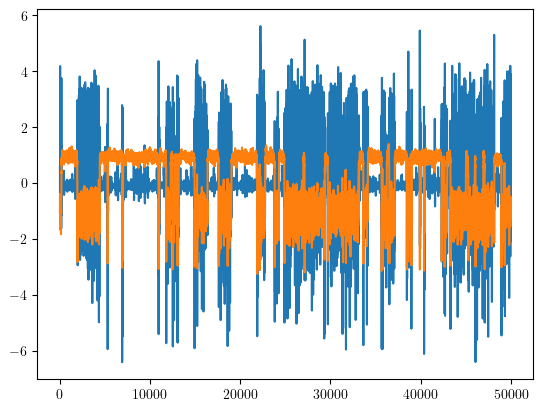

In [2]:
# Init pack

import numpy as np
import h5py
import numpy as np
from scipy.integrate import solve_ivp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sys
import torch
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast
from torch.nn.parallel import DataParallel
plt.rcParams['text.usetex'] = True

psi = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')

psi = psi[:,1,:]

# Normalization
mean_psi = np.mean(psi, axis=0, keepdims=True)
std_psi = np.std(psi, axis=0, keepdims=True)
psi = (psi - mean_psi) / std_psi

# Pre-processing

lead = 1
trainN = 250000
valN = 50000
index = 63

# Defining the variable ranges
variable_range = [(0,24), (25, 49), (50, 74), (0, 49), (0,74)]

# Select the variable: 0 for real perturbation, 1 for imaginary perturbation, 2 for zonal winds
variable = 3
num_variables = variable_range[variable][1] - variable_range[variable][0] + 1

# Shuffle and map indices
np.random.seed(42)
valid_indices = np.arange(0, trainN - lead)
shuffled_indices = np.random.permutation(valid_indices)

# Now constrain the shuffled indices to the variable range
np_psi_train_input = psi[shuffled_indices, variable_range[variable][0]:variable_range[variable][1]+1]
np_psi_train_label = psi[shuffled_indices + lead, :]

psi_train_input = torch.tensor(np_psi_train_input)
psi_train_label = torch.tensor(np_psi_train_label)

np_psi_val_input = psi[trainN:trainN+valN, variable_range[variable][0]:variable_range[variable][1]+1]
np_psi_val_label = psi[trainN+lead:trainN+valN+lead, :]
psi_val_input = torch.tensor(np_psi_val_input)
psi_val_label =  torch.tensor(np_psi_val_label)

plt.plot(np_psi_val_input[:,-1]) # Real and Imaginary PSI
plt.plot(np_psi_val_label[:,-1]) # Real and Imaginary PSI + Zonal Wind
plt.show()
# plt.plot(psi_val_input[0:50000,63])

In [3]:
# Define the encoder (MLP)
class Encoder(nn.Module):
    def __init__(self, latent_dim, num_neurons):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(75, num_neurons)  # Input layer (2 + 2) -> Hidden layer (128)
        self.fc2 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc3 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc4 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc5 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc6 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc_mu = nn.Linear(num_neurons, latent_dim)  # Hidden layer (128) -> Latent space (2)
        self.fc_logvar = nn.Linear(num_neurons, latent_dim)  # Hidden layer (128) -> Log variance (2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Activation function for hidden layer
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# Define the decoder (MLP)
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + condition_dim, num_neurons)  # Input layer (2 + 2) -> Hidden layer (128)
        self.fc2 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc3 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc4 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc5 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc6 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc_output = nn.Linear(num_neurons, output_dim)  # Hidden layer (128) -> Output layer (2)

    def forward(self, z, condition):
        z = torch.cat((z, condition), dim=1)  # Concatenate latent vector and condition
        z = torch.relu(self.fc1(z))  # Activation function for hidden layer
        z = torch.relu(self.fc2(z)) + z
        z = torch.relu(self.fc3(z)) + z
        z = torch.relu(self.fc4(z)) + z
        z = torch.relu(self.fc5(z)) + z
        z = torch.relu(self.fc6(z)) + z
        output = self.fc_output(z)
        return output

# Define the VAE model
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(ConditionalVAE, self).__init__()
        self.encoder = Encoder(latent_dim, num_neurons)
        self.decoder = Decoder(latent_dim, output_dim, condition_dim, num_neurons)

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z, condition):
        return self.decoder(z, condition)

    def forward(self, x, condition):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z, condition)
        return output, mu, logvar

output_dim = 75
latent_dim = 32
condition_dim = num_variables
batch_size = 1024

In [4]:
# TO-DO: Check if crps is correct

from scipy.stats import linregress

import warnings
from torch.serialization import SourceChangeWarning
warnings.filterwarnings("ignore", category=UserWarning)

def normalize_transition_time(s, dlt, r):
    """
    Normalize the transition time based on the specified delta and reference value.

    Args:
        s (float): The transition time to normalize.
        dlt (float): The delta value for normalization.
        r (float): The reference value for normalization.

    Returns:
        norm (float): The normalized transition time.
    """
    norm = 1 - np.exp(-np.abs((s - r)) / dlt)
    return norm

# Code from Ira Shokar but slightly changed
def crps_score(p, y):
    """
    Calculate CRPS for given predictions and observations.

    Args:
        p (Tensor): Predictions, shape (N, D) where N = ens_num and D is the dimension of the prediction.
        y (Tensor): Observations, shape (D) where D is the dimension of the observation.

    Returns:
        crps (float): The CRPS score.
    """
    y  = y.unsqueeze(0)
    # First term: mean distance from observations to ensemble members
    mae     = torch.cdist(y, p, 1).mean()
    # Second term: mean distance between ensemble members (properly normalized)
    ens_var = torch.cdist(p, p, 1).mean()
    
    return mae - 0.5 * ens_var

# Function to calculate transition durations
def calculate_transition_durations(y, u, l):
    """
    Calculate the return periods with user-defined upper and lower bounds.

    Args:
        y (np.array): The time series data.
        u (float): The upper bound for the transition.
        l (float): The lower bound for the transition.

    Returns:
        t_times (list): The list of return periods for transitions.
    """

    t_times = []
    s = None
    above_u = False
    below_l = False
    for i in range(1, len(y)):
        
        if y[i] < l:
            if above_u and s is not None:
                t_times.append(i-s)  
            below_l = True
            above_u = False

        elif y[i] > u:  
            if below_l and s is not None:
                t_times.append(i - s)
                s = None  
            above_u = True
            below_l = False

        if below_l and s is None:
            s = i

        if above_u and s is None:
            s = i
    return t_times

def KL_coefficient(r, p, delta, cycle, KL_by_dim_cycle):
    """
    Calculate the KL divergence between two distributions and normalize it.

    Args:
        r (np.array): Real distribution.
        p (np.array): Predicted distribution.
        delta (float): Delta value for normalization.
        cycle (int): Cycle number for tracking.
        KL_by_dim_cycle (dict): Dictionary to store KL divergence values by dimension and cycle.

    Returns:
        r (np.array): Processed real distribution.
        p (np.array): Processed predicted distribution.
        nkl (float): Normalized KL divergence.
    """
    # Calculating KL divergence
    r = r[:30000, 1, 63]
    p = p[:30000]
    
    rh, b = np.histogram(r, bins=50, density=True)
    ph, _ = np.histogram(p, bins=b, density=True)

    e = 1e-10
    rh += e
    ph += e

    # Calculate KL divergence between the two histograms
    kl = np.sum(rh * np.log(rh / ph))
    nkl = normalize_transition_time(kl, 1, 0)

    print(f"Normalized KL divergence for delta {delta}, cycle {cycle}: {nkl:.6f}")
    KL_by_dim_cycle[delta][cycle].append(nkl)

    return r, p, nkl

def CCDF_fit(p_times, s):
    """
    Calculate the slope of the CCDF of transition times and normalize it.

    Args:
        p_times (list): Transition times from predictions.
        s (float): Real value for normalization.
    
    Returns:
        np_slope (float): Normalized slope of the CCDF.
    """
    # === PREDICTIONS CCDF AND FIT ===
    if len(p_times) > 0 and len(np.unique(p_times)) > 1:
        sp_times = np.sort(p_times)
        p_ccdf = 1 - np.arange(1, len(sp_times) + 1) / len(sp_times)

        p_v_indices = p_ccdf > 0
        px_fit = sp_times[p_v_indices]
        py_fit = np.log(p_ccdf[p_v_indices])

        p_slope, _, *_ = linregress(px_fit, py_fit)
        np_slope = normalize_transition_time(p_slope, 0.005, s)
        return np_slope

    else:
        print("No transitions detected in predictions for CCDF slope evaluation.")

def Mean_and_std_of_predictions(p_times, r_times, dlt, cc, transitions_by_dim_cycle, transitions_normalized_by_dim_cycle, transitions_normalized_std_by_dim_cycle):
    """
    Calculate the mean and standard deviation of transition times from predictions and normalize them.

    Args:
        p_times (list): Transition times from predictions.
        r_times (list): Transition times from real data.
        dlt (float): Delta value for normalization.
        cc (int): Cycle number for tracking.
        transitions_by_dim_cycle (dict): Dictionary to store transition times by dimension and cycle.
        transitions_normalized_by_dim_cycle (dict): Dictionary to store normalized transition times by dimension and cycle.
        transitions_normalized_std_by_dim_cycle (dict): Dictionary to store normalized standard deviations by dimension and cycle.

    Returns:
        npd_mean (float): Normalized mean of transition times.
        npd_std (float): Normalized standard deviation of transition times.
    """
    p_mean = np.mean(p_times)
    p_std = np.std(p_times)

    pd_mean = abs(p_mean - np.mean(r_times))
    pd_std = abs(p_std - np.std(r_times))

    npd_mean = normalize_transition_time(pd_mean, 1000, np.mean(r_times))
    npd_std = normalize_transition_time(pd_std, 1000, np.std(r_times))

    npd_std = 1 if npd_std == 0 else npd_std

    transitions_by_dim_cycle[dlt][cc].append(pd_mean)
    transitions_normalized_by_dim_cycle[dlt][cc].append(npd_mean)
    transitions_normalized_std_by_dim_cycle[dlt][cc].append(npd_std)

    return npd_mean, npd_std

# KL Annealing (FROM PAPER)
def frange_cycle_linear(start, stop, n_epoch, n_cycle=4, ratio=0.5):
    """
    Generate a linear schedule for KL annealing over multiple cycles.

    Args:
        start (float): Starting value of the schedule.
        stop (float): Stopping value of the schedule.
        n_epoch (int): Total number of epochs.
        n_cycle (int): Number of cycles for the schedule.
        ratio (float): Ratio of the cycle length to the total number of epochs.

    Returns:
        L (np.array): Array containing the linear schedule values for each epoch.
    """
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # linear schedule

    for c in range(n_cycle):

        v , i = start , 0
        while v <=stop and (int(i+c*period) < n_epoch):
            L[int(i+c*period)] = v
            v += step
            i += 1
    return L

In [4]:
# PREP

import os, random
import itertools

real_data       = np.load("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
save_dir        = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths"
os.makedirs(save_dir, exist_ok=True)

num_samples     = 1000
level           = 63
start, end      = (0, 50)

latent_dim      = 32
output_dim      = 75
condition_dim   = 50
num_neurons     = 1024

model_path      = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/best_models_kinda/checkpoint_11"

model           = ConditionalVAE(latent_dim, output_dim, condition_dim, num_neurons).cuda()
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Loading model from checkpoint...")
model.eval()

RuntimeError: No CUDA GPUs are available

In [5]:
# timesteps = 300_000
# initial_cond = torch.reshape(torch.tensor(psi[0, start:end]), [1, num_variables]).float().cuda()
# z = torch.zeros((1, latent_dim))
# save = np.zeros((timesteps, 75))

# for timestep in range(timesteps):
#     with torch.no_grad():

#         z = torch.randn_like(z).float().cuda()
#         y = model.decode(z, initial_cond)
#         save[timestep, :] = y.cpu().numpy()
#         initial_cond = y[:, start:end].float().cuda()

# print(std_psi.shape, mean_psi.shape)
# save = save * std_psi + mean_psi
# actual = psi[:timesteps, level] * std_psi[0, level] + mean_psi[0, level]
# plt.figure(figsize=(10,6))
# plt.plot(save[:, level], label='Predicted', color='red', alpha=0.7)
# plt.plot(actual, label='Real', color='blue', alpha=0.7)
# plt.xlabel('Timestep')
# plt.ylabel('Zonal Wind at Level 63')
# plt.title('Zonal Wind Prediction vs Real Data')
# plt.legend()
# plt.grid()
# plt.show()

# np.save(os.path.join(save_dir, f"single_timestep_prediction_level_{level}_300_000.npy"), save)

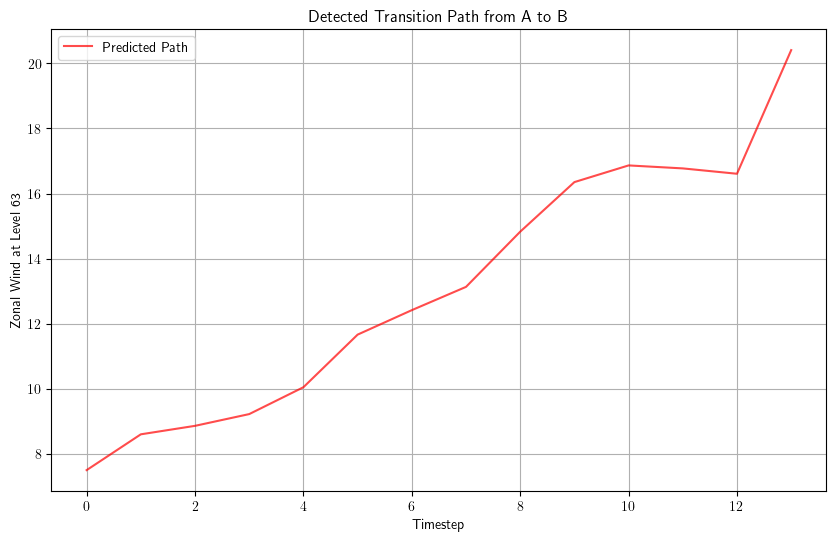

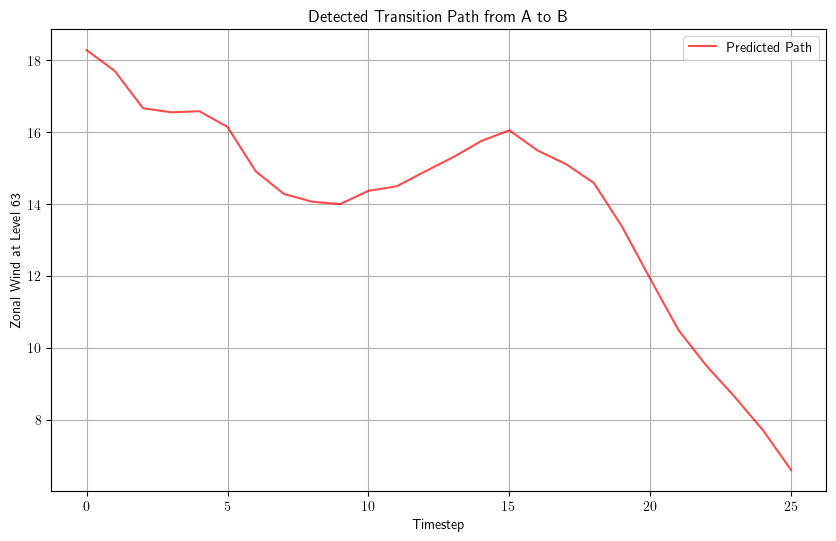

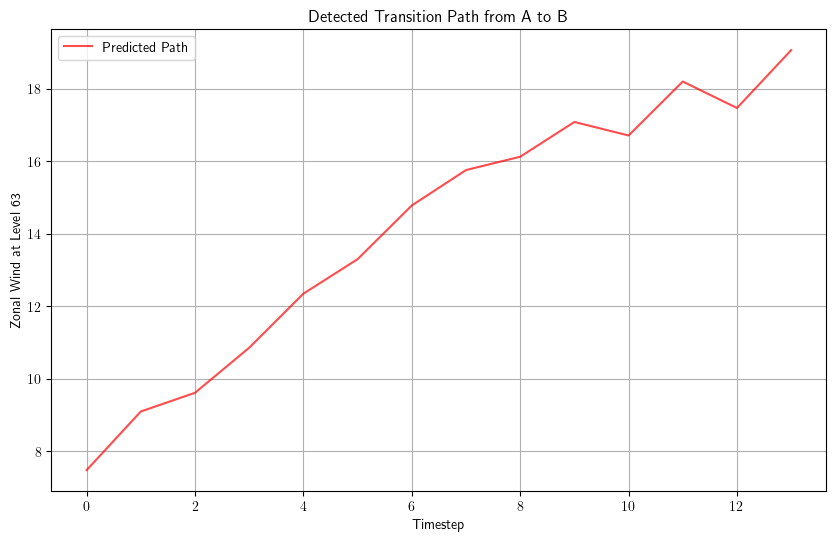

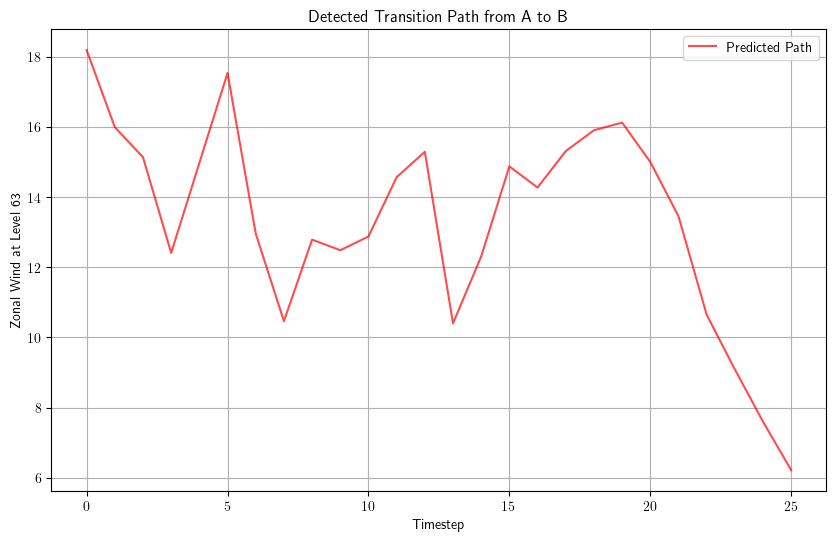

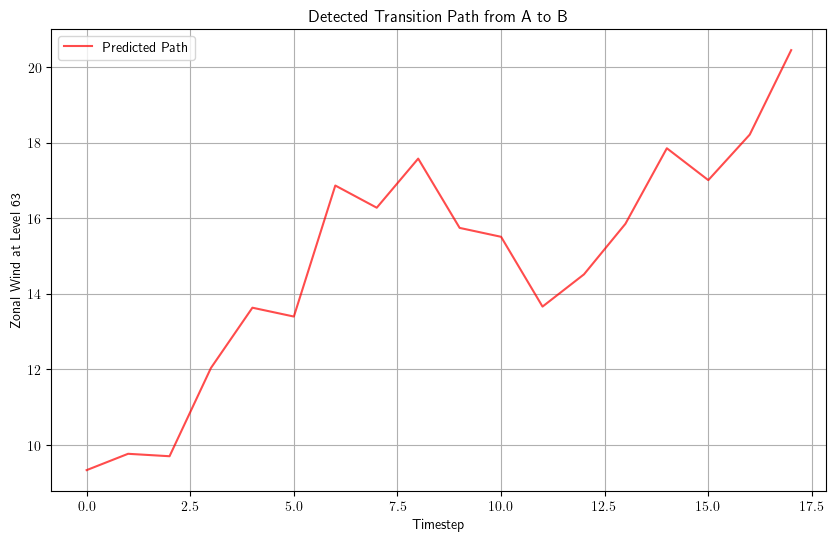

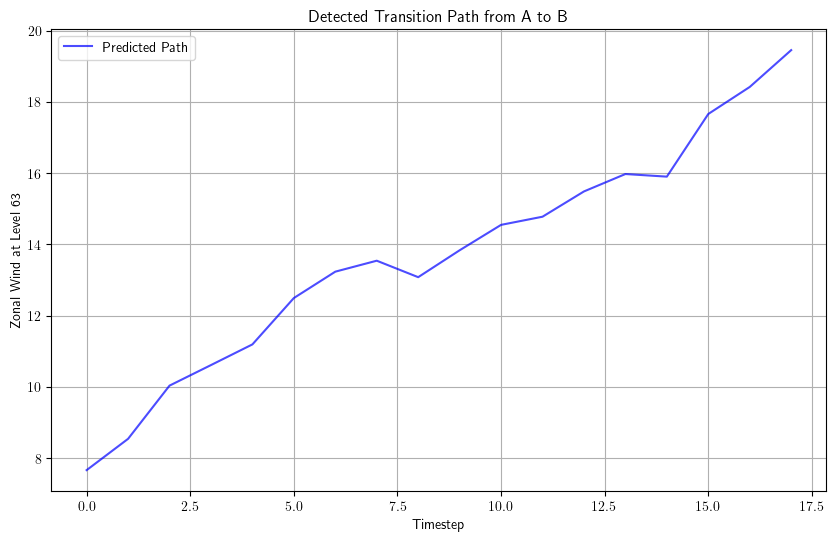

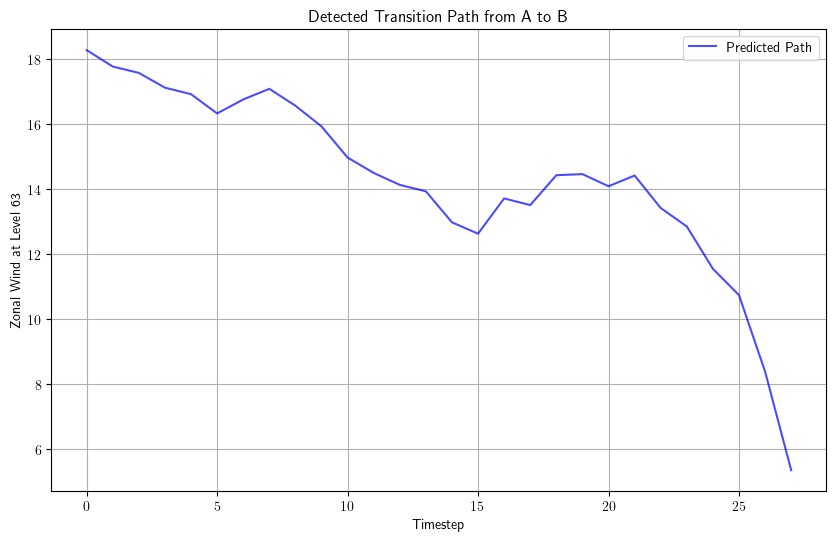

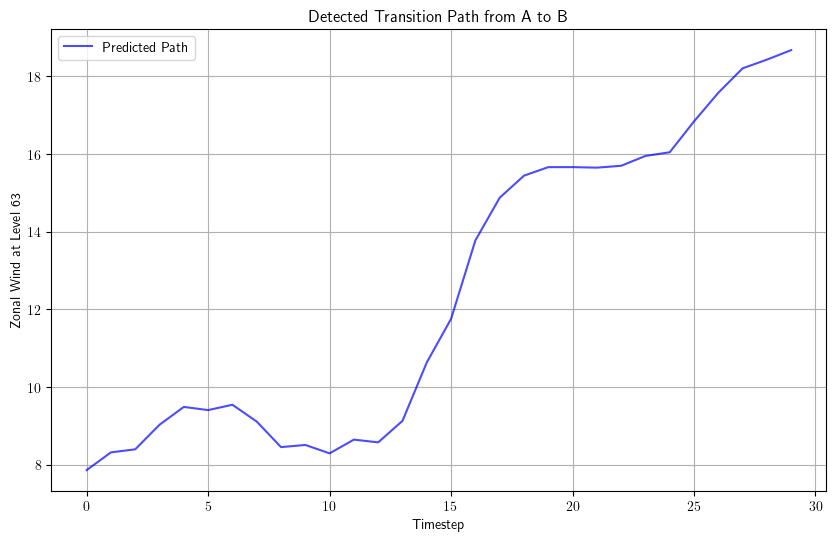

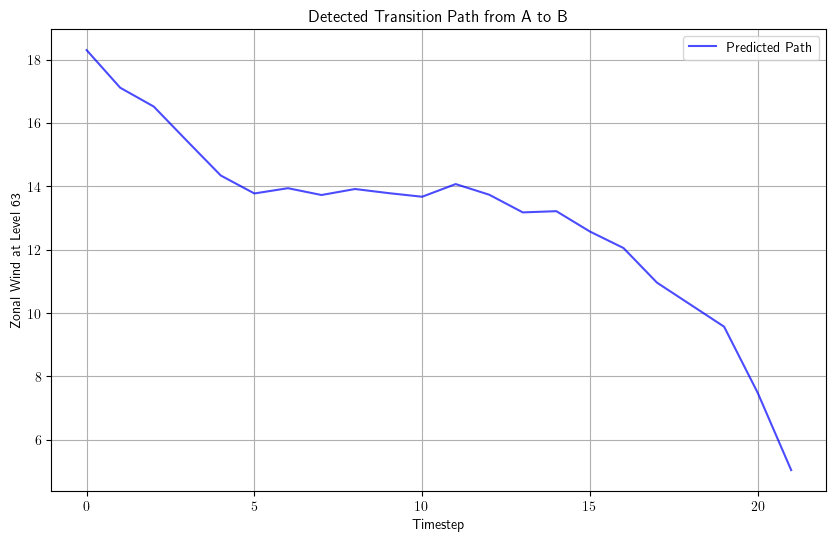

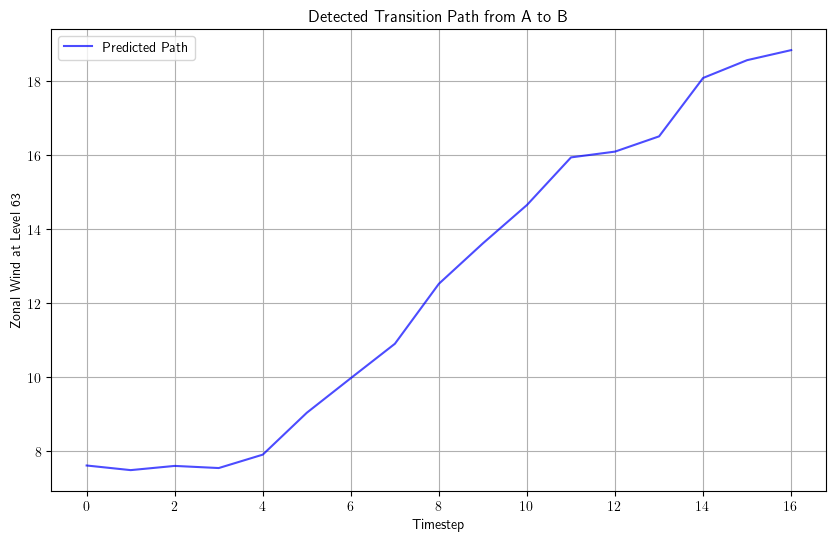

In [7]:
# Detecting A to B transitions

timesteps = 300_000
upper_bound = 18.59
lower_bound = 7.41
level = 63
A = False
B = True
T = False

save = np.load("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths/single_timestep_prediction_level_63_300_000.npy")
save = save[:, :]
actual = np.load("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
actual = actual[:timesteps,1,:]

paths = []

for i in range(timesteps):
    if save[i, level] > upper_bound:
        if T and not A:
            paths.append((d_save, i))
        A = True
        B = False
        T = False
    if save[i, level] < lower_bound:
        if T and not B:
            paths.append((d_save, i))
        B = True
        A = False
        T = False
    if lower_bound <= save[i, level] <= upper_bound and not T:
        T = True
        d_save = i  # d_save captures the START of transition

    # if save[i, level] < upper_bound and not B and not T:
    #     T = True
    #     d_save = i
    # if save[i, level] > lower_bound and not A and not T:
    #     T = True
    #     d_save = i
    # if save[i, level] > upper_bound and T and not A:
    #     A = True
    #     B = False
    #     T = False
    #     paths.append((d_save, i))
    # if save[i, level] < lower_bound and T and not B:
    #     B = True
    #     A = False
    #     T = False
    #     paths.append((d_save, i))

for path in paths[:5]:
    start_of_path, end_of_path = path
    plt.figure(figsize=(10,6))
    plt.plot(save[start_of_path:end_of_path+1, level], label='Predicted Path', color='red', alpha=0.7)
    plt.xlabel('Timestep')
    plt.ylabel('Zonal Wind at Level 63')
    plt.title('Detected Transition Path from A to B')
    plt.legend()
    plt.grid()
    plt.show()

real_paths = []
unnorm_psi = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')
unnorm_psi = unnorm_psi[:timesteps,1,:]
for i in range(timesteps):
    if unnorm_psi[i, level] > upper_bound:
        if T and not A:
            real_paths.append((d_save, i))
        A = True
        B = False
        T = False
    if unnorm_psi[i, level] < lower_bound:
        if T and not B:
            real_paths.append((d_save, i))
        B = True
        A = False
        T = False
    if lower_bound <= unnorm_psi[i, level] <= upper_bound and not T:
        T = True
        d_save = i  # d_save captures the START of transition

for path in real_paths[:5]:
    start_of_path, end_of_path = path
    plt.figure(figsize=(10,6))
    plt.plot(unnorm_psi[start_of_path:end_of_path+1, level], label='Predicted Path', color='blue', alpha=0.7)
    plt.xlabel('Timestep')
    plt.ylabel('Zonal Wind at Level 63')
    plt.title('Detected Transition Path from A to B')
    plt.legend()
    plt.grid()
    plt.show()

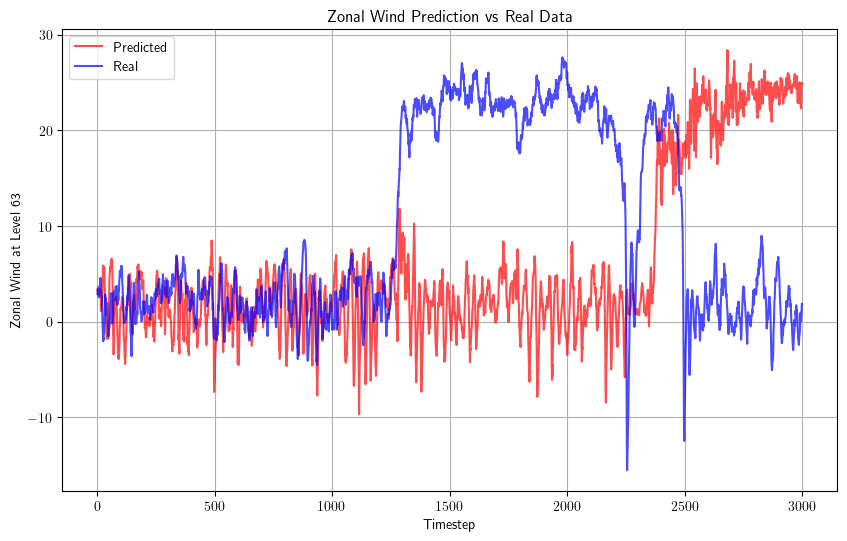

In [8]:
plt.figure(figsize=(10,6))
plt.plot(save[:3000, level], label='Predicted', color='red', alpha=0.7)
plt.plot(actual[:3000, level], label='Real', color='blue', alpha=0.7)
plt.xlabel('Timestep')
plt.ylabel('Zonal Wind at Level 63')
plt.title('Zonal Wind Prediction vs Real Data')
plt.legend()
plt.grid()
plt.show()

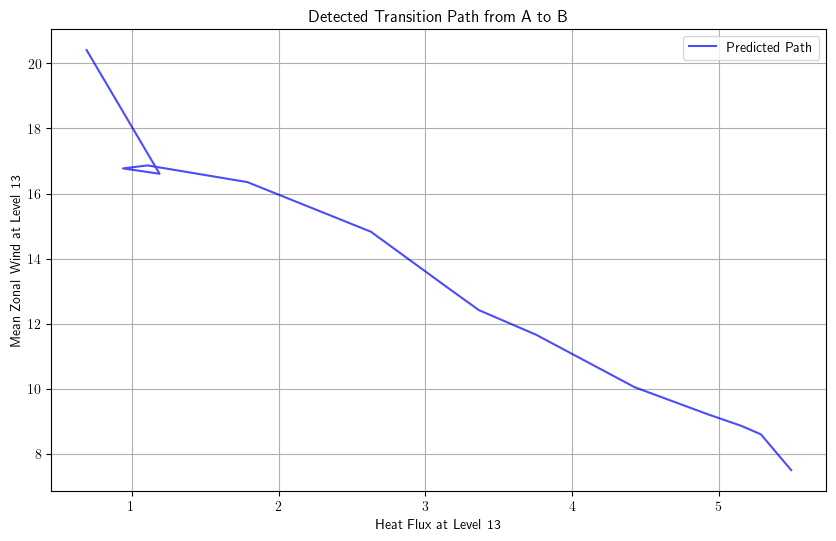

(300000, 25)


In [9]:
from scipy import sparse as sps

def D1mat(n,dz,lower_value,lower_type,upper_value,upper_type):
    # coeff is the coefficient to multiply the derivative by
    D = np.zeros((n,n))
    C = np.zeros(n)
    D[np.arange(1,n-1),np.arange(2,n)] = 1.0/(2*dz)
    D[np.arange(1,n-1),np.arange(n-2)] = -1.0/(2*dz)
    # Lower boundary
    if lower_type == 'dirichlet':
        D[0,1] = 1.0/(2*dz)
        C[0] = -lower_value/(2*dz)
    elif lower_type == 'neumann':
        D[0,[0,1]] = 2.0/3*np.array([-1,1])/dz
        C[0] = 1.0/3*lower_value
    # Upper boundary
    if upper_type == 'dirichlet':
        D[n-1,n-2] = -1.0/(2*dz)
        C[n-1] = upper_value/(2*dz)
    elif upper_type == 'neumann':
        D[n-1,[n-2,n-1]] = 2.0/3*np.array([-1,1])/dz
        C[n-1] = 1.0/3*upper_value
    return C,D

def D2mat(n,dz,lower_value,lower_type,upper_value,upper_type):
    D = np.zeros((n,n))
    C = np.zeros(n)
    D[np.arange(1,n-1),np.arange(1,n-1)] = -2.0/dz**2
    D[np.arange(1,n-1),np.arange(n-2)] = 1.0/dz**2
    D[np.arange(1,n-1),np.arange(2,n)] = 1.0/dz**2
    # Lower boundary
    if lower_type == 'dirichlet':
        D[0,[0,1]] = np.array([-2,1])/dz**2
        C[0] = lower_value/dz**2
    elif lower_type == 'neumann':
        D[0,[0,1]] = np.array([-1,1])/(1.5*dz**2)
        C[0] = -1.0/(1.5*dz)*lower_value
    # Upper boundary
    if upper_type == 'dirichlet':
        D[n-1,[n-2,n-1]] = np.array([1,-2])/dz**2
        C[n-1] = upper_value/dz**2
    elif upper_type == 'neumann':
        D[n-1,[n-2,n-1]] = -np.array([-1,1])/(1.5*dz**2)
        C[n-1] = 1.0/(1.5*dz)*upper_value
    return C,D

def first_derivative(F,lower,upper,dz):
    # Compute the first z derivatives any field
    Nt,n = F.shape
    Fz = np.zeros([Nt,n])
    Fz[:,1:-1] = (F[:,2:n] - F[:,0:n-2]) / (2*dz)
    Fz[:,0] = (F[:,1] - lower)/(2*dz)
    Fz[:,-1] = (upper - F[:,-2])/(2*dz)
    return Fz

def second_derivative(F,lower,upper,dz):
    # Compute the first z derivatives any field
    Nt,n = F.shape
    Fzz = np.zeros([Nt,n])
    Fzz[:,1:-1] = (F[:,2:n] + F[:,0:n-2] - 2*F[:,1:-1]) / (dz**2)
    Fzz[:,0] = (F[:,1] + lower - 2*F[:,0])/(dz**2)
    Fzz[:,-1] = (upper + F[:,-2] - 2*F[:,-1])/(dz**2)
    return Fzz

tau = 0.25
kappa = 0.0
sigma = 1.0
state_dim = 2
dt_sim = 0.0001
obs_dim = 2 # Observable degrees of freedom
ref_alt = 30.0
hB_d = 38.5
physical_params = dict({
    'tau': tau,
    'kappa': kappa,
    'sigma': sigma,
    'state_dim': state_dim,
    'obs_dim': obs_dim,
    'dt_sim': dt_sim,
    'ref_alt': ref_alt,
    'hB_d': hB_d,
    'du_per_day': 1.0,
    'dt_sim': 0.005,
    })

q = {
           'rad': 6370.0e3, 'day': 24*3600.0, 'g': 9.82, 'phi0': np.pi/3, 
           'sx': 2, 'sy': 3, 'zB_d': 0.0, 'zT_d': 70.0e3, 'H': 7.0e3, 
           'Omega': 2*np.pi/(24*3600), 'Nsq_d': 4.0e-4, 'ideal_gas_constant': 8.314,
           'eps': 8.0/(3*np.pi), 'UR_0_d': 10.0, 'gamma': 1.5, 'hB_d': physical_params['hB_d'], 
           'nfreq': 3, 'Nz': 26, 'length': 2.5e5, 'time': 24*3600.0,
           'du_per_day': physical_params['du_per_day'], 'dt_sim': physical_params['dt_sim'],
        }

n = q['Nz']+1 #Number of points including boundaries
q['state_dim'] = 3*(q['Nz']-1)
#Dimensional variables
q['f0_d'] = 2*q['Omega']*np.sin(q['phi0'])
q['beta_d'] = 2*q['Omega']*np.cos(q['phi0'])/q['rad']
q['k_d'] = q['sx']/(q['rad']*np.cos(q['phi0']))
q['l_d'] = q['sy']/q['rad']
q['dz_d'] = (q['zT_d']-q['zB_d'])/q['Nz']
q['z_d'] = np.linspace(q['zB_d'],q['zT_d'],q['Nz']+1)
q['alpha_d'] = (1.5 + np.tanh((q['z_d']/1000-25)/7.0))*1e-6
q['alpha_z_d'] = 1e-6/7000 * 1.0/np.cosh((q['z_d']/1000-25)/7.0)**2
q['UR_d'] = q['UR_0_d'] + q['gamma']*q['z_d']/1000
q['UR_z_d'] = q['gamma']/1000*np.ones(n)
q['UR_zz_d'] = np.zeros(n)
q['Psi0_d'] = q['g']*q['hB_d']/q['f0_d']
q['fn'] = q['f0_d']**2/q['Nsq_d']
q['lap_d'] = q['k_d']**2 + q['l_d']**2 + 1.0/(4*q['H']**2)*q['fn']
#Dimensionless variables
q['Gsq'] = 1.0/(q['length']**2/q['H']**2*q['fn'])
q['k'] = q['k_d']*q['length']
q['l'] = q['l_d']*q['length']
q['dz'] = q['dz_d']/q['H']
q['zT'] = q['zT_d']/q['H']
q['zB'] = q['zB_d']/q['H']
q['z'] = q['z_d']/q['H']
q['beta'] = q['beta_d']*q['time']*q['length']
q['alpha'] = q['alpha_d']*q['time']
q['alpha_z'] = q['alpha_z_d']*q['time']*q['H']
q['UR'] = q['UR_d']*q['time']/q['length']
q['UR_0'] = q['UR_0_d']*q['time']/q['length']
q['UR_z'] = q['UR_z_d']*q['time']*q['H']/q['length']
q['UR_zz'] = q['UR_zz_d']*q['time']*q['H']**2/q['length']
q['lap'] = q['Gsq']*(q['k']**2 + q['l']**2) + 1/4.0
q['Psi0'] = q['Psi0_d']*q['time']/q['length']**2
#Some handy shortcuts
ref_alt = physical_params['ref_alt']
q['zi'] = np.argmin(np.abs(q['z_d'][1:-1]/1000-ref_alt))
q['states'] = ['r','v']
#Noise
q['sig_u'] = q['du_per_day']*np.sqrt(q['time']**3/q['length']**2/(3600.0*24))
n = q['Nz']-1
sigmat = np.zeros((3*n,q['nfreq'])) 
# Wdot = np.zeros(3*n)
for k in range(q['nfreq']):
    sinkz_shift = np.sin((k+0.5)*np.pi*q['z']/q['zT'])[1:-1]
    sigmat[2*n:,k] = q['sig_u']*sinkz_shift
    # Wdot[[k,n+k,2*n+k]] = mag[k]
q['sig_mat'] = sps.csr_matrix(sigmat)
# Left-hand inversion operator
Lpsi = np.zeros((n,n))
Lu = np.zeros((n,n))
Lpsi[np.arange(n),np.arange(n)] = -(q['Gsq']*(q['k']**2+q['l']**2) + 0.25) - 2.0/q['dz']**2
Lpsi[np.arange(n-1),np.arange(1,n)] = 1.0/q['dz']**2
Lpsi[np.arange(1,n),np.arange(n-1)] = 1.0/q['dz']**2
Lu[np.arange(n),np.arange(n)] = -q['Gsq']*q['l']**2 - 2.0/q['dz']**2
Lu[np.arange(n-1),np.arange(1,n)] = -1.0/(2*q['dz']) + 1.0/q['dz']**2
Lu[np.arange(1,n),np.arange(n-1)] = 1.0/(2*q['dz']) + 1.0/q['dz']**2
# Boundary!
Lu[n-1,n-2] = 2.0/(3*q['dz']) + 2.0/(3*q['dz']**2)
Lu[n-1,n-1] = -q['Gsq']*q['l']**2 - 2.0/(3*q['dz']) - 2.0/(3*q['dz']**2)
# Invert
q['Lpsi_inv'] = sps.csr_matrix(np.linalg.inv(Lpsi))
q['Lu_inv'] = sps.csr_matrix(np.linalg.inv(Lu))
dz = q['dz']
Xz_vec,Xz_mat = D1mat(n,dz,q['Psi0'],'dirichlet',0,'dirichlet')
Xzz_vec,Xzz_mat = D2mat(n,dz,q['Psi0'],'dirichlet',0,'dirichlet')
Yz_vec,Yz_mat = D1mat(n,dz,0,'dirichlet',0,'dirichlet')
Yzz_vec,Yzz_mat = D2mat(n,dz,0,'dirichlet',0,'dirichlet')
Uz_vec,Uz_mat = D1mat(n,dz,q['UR_0'],'dirichlet',q['UR_z'][-1],'neumann')
Uzz_vec,Uzz_mat = D2mat(n,dz,q['UR_0'],'dirichlet',q['UR_z'][-1],'neumann')
# Get constant and linear parts first
Jlin = np.zeros((3*n,3*n))
# Re(Psi)
a = q['alpha'][1:-1]
az = q['alpha_z'][1:-1]
Jlin[:n,:n] += np.diag(a/4-az/2) - (az*Xz_mat.T + a*Xzz_mat.T).T
Jlin[:n,n:2*n] += q['Gsq']*q['k']*q['beta']*np.eye(n)
# Im(Psi)
Jlin[n:2*n,n:2*n] += np.diag(a/4-az/2) - (az*Yz_mat.T + a*Yzz_mat.T).T
Jlin[n:2*n,:n] += -q['Gsq']*q['k']*q['beta']*np.eye(n)
# U
Jlin[2*n:3*n,2*n:3*n] = -((az-a)*Uz_mat.T + a*Uzz_mat.T).T

# INTEGRATED HEAT FLUX
n = q['Nz']-1
x = save  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
ivt = np.zeros((Nt,n))
ivt[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    ivt[:,i] = ivt[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

# # WEIGHTED HEAT FLUX
# n = q['Nz']-1
# x = save  # Use the 'save' array as 'x'
# Nt = len(x)
# heat_flux = np.ones([Nt,n])
# heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
# #heat_flux *= np.exp(q['z'][:-1])*17.0/35
# # Now it has to be multiplied by vertical derivatives
# Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
# Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
# Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
# heat_flux *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
# heat_flux *= np.exp(-q['z'][1:-1])

# path = paths[0]
# start_of_path, end_of_path = path
# plt.figure(figsize=(10,6))
# plt.plot(heat_flux[start_of_path:end_of_path+1, level-50], save[start_of_path:end_of_path+1, level], label='Predicted Path', color='blue', alpha=0.7)
# plt.xlabel('Heat Flux at Level 13')
# plt.ylabel('Mean Zonal Wind at Level 13')
# plt.title('Detected Transition Path from A to B')
# plt.legend()
# plt.grid()
# plt.show()

path = paths[0]
start_of_path, end_of_path = path
plt.figure(figsize=(10,6))
plt.plot(ivt[start_of_path:end_of_path+1, level-50], save[start_of_path:end_of_path+1, level], label='Predicted Path', color='blue', alpha=0.7)
plt.xlabel('Heat Flux at Level 13')
plt.ylabel('Mean Zonal Wind at Level 13')
plt.title('Detected Transition Path from A to B')
plt.legend()
plt.grid()
plt.show()

print(ivt.shape)

In [10]:
# Calculating the range of mean zonal wind, streamfunction and heat flux
max_u = np.max(save[:, level])
min_u = np.min(save[:, level])
range_u = max_u - min_u

streamfunction = save[:, level-50]**2 + save[:, 2*(level-50)]**2
max_psi = np.max(streamfunction)
min_psi = np.min(streamfunction)
range_psi = max_psi - min_psi

max_ivt = np.max(ivt[:, level-50])
min_ivt = np.min(ivt[:, level-50])
range_ivt = max_ivt - min_ivt

print(f"Zonal Wind at Level {level-50}: Max = {max_u:.2f}, Min = {min_u:.2f}, Range = {range_u:.2f}")
print(f"Streamfunction at Level {level-50}: Max = {max_psi:.2f}, Min = {min_psi:.2f}, Range = {range_psi:.2f}")
print(f"IVT at Level {level-50}: Max = {max_ivt:.2f}, Min = {min_ivt:.2f}, Range = {range_ivt:.2f}")

Zonal Wind at Level 13: Max = 29.57, Min = -16.65, Range = 46.22
Streamfunction at Level 13: Max = 284.75, Min = 0.00, Range = 284.75
IVT at Level 13: Max = 15.60, Min = -5.42, Range = 21.02


(300000, 25) 8.046645919424945
Zonal Wind at Level 13: Max = 29.84, Min = -19.84, Range = 49.68
Streamfunction at Level 13: Max = 382.44, Min = 0.00, Range = 382.44
IVT at Level 13: Max = 17.48, Min = -3.67, Range = 21.15


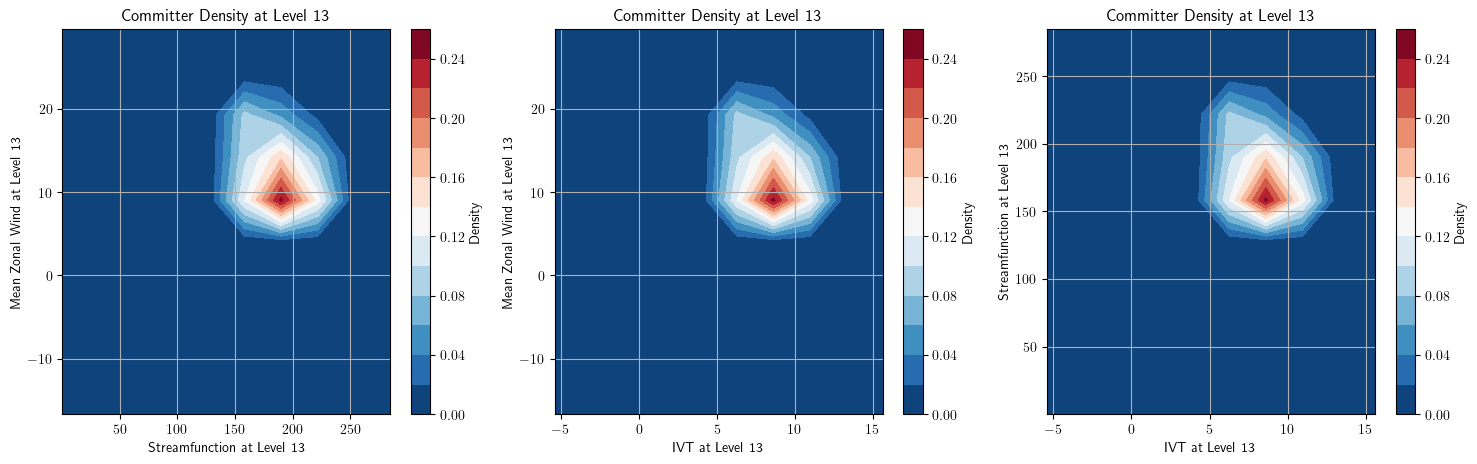

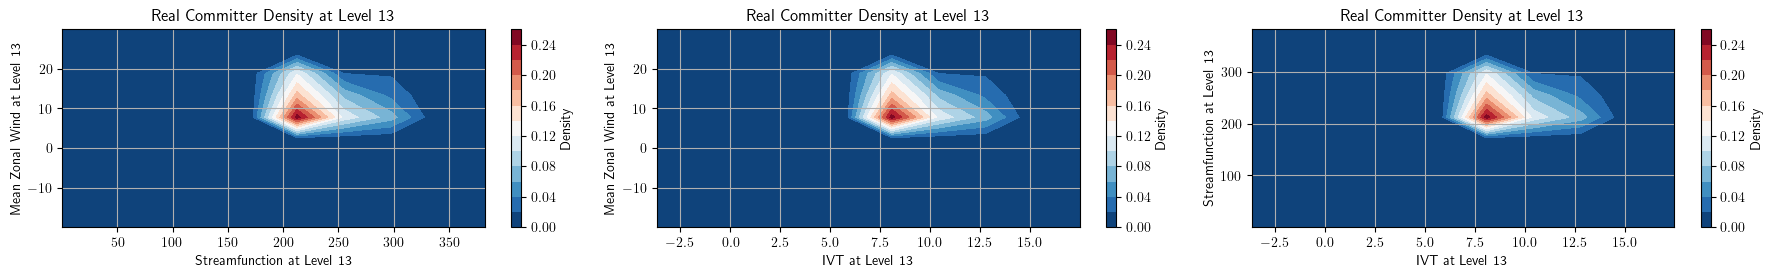

In [11]:
bin_size_u = range_u / 10
bin_size_psi = range_psi / 10
bin_size_ivt = range_ivt / 10

# Committer for A to B transitions and its density for mean zonal wind, streamfunction and heat flux. This includes both states A and B in the probabilities

comm_matrix = np.zeros((10, 10))

for i in range(1, len(paths), 2):  # Step by 2 to get only A to B transitions
    path = paths[i]
    start_of_path, end_of_path = path
    for i in range(start_of_path, end_of_path + 1):
        u_val = save[i, level]
        psi_val = streamfunction[i]
        ivt_val = ivt[i, level-50]

        u_bin = int((u_val - min_u) / bin_size_u)
        psi_bin = int((psi_val - min_psi) / bin_size_psi)
        ivt_bin = int((ivt_val - min_ivt) / bin_size_ivt)

        u_bin = min(max(u_bin, 0), 9)
        psi_bin = min(max(psi_bin, 0), 9)
        ivt_bin = min(max(ivt_bin, 0), 9)

        comm_matrix[u_bin, psi_bin] += 1
        comm_matrix[u_bin, ivt_bin] += 1
        comm_matrix[psi_bin, ivt_bin] += 1

for i in range(10):
    min_val = min_u + i * bin_size_u
    max_val = min_u + (i + 1) * bin_size_u

    if max_val > upper_bound and min_val > upper_bound:
        comm_matrix[i, :] = 0
        comm_matrix[:, i] = 0

    if max_val < lower_bound and min_val < lower_bound:
        comm_matrix[i, :] = 1
        comm_matrix[:, i] = 1

# Normalize the committer matrix to get probabilities
comm_matrix /= np.sum(comm_matrix)

# Calculating the range of mean zonal wind, streamfunction and heat flux
real_max_u = np.max(unnorm_psi[:, level])
real_min_u = np.min(unnorm_psi[:, level])
real_range_u = real_max_u - real_min_u

real_streamfunction = unnorm_psi[:, level-50]**2 + unnorm_psi[:, 2*(level-50)]**2
real_max_psi = np.max(real_streamfunction)
real_min_psi = np.min(real_streamfunction)
real_range_psi = real_max_psi - real_min_psi

n = q['Nz']-1
x = unnorm_psi  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
real_ivt = np.zeros((Nt,n))
real_ivt[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    real_ivt[:,i] = real_ivt[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

print(real_ivt.shape, real_ivt[0, 13])
real_max_ivt = np.max(real_ivt[:, level-50])
real_min_ivt = np.min(real_ivt[:, level-50])
real_range_ivt = real_max_ivt - real_min_ivt

print(f"Zonal Wind at Level {level-50}: Max = {real_max_u:.2f}, Min = {real_min_u:.2f}, Range = {real_range_u:.2f}")
print(f"Streamfunction at Level {level-50}: Max = {real_max_psi:.2f}, Min = {real_min_psi:.2f}, Range = {real_range_psi:.2f}")
print(f"IVT at Level {level-50}: Max = {real_max_ivt:.2f}, Min = {real_min_ivt:.2f}, Range = {real_range_ivt:.2f}")

real_bin_size_u = real_range_u / 10
real_bin_size_psi = real_range_psi / 10
real_bin_size_ivt = real_range_ivt / 10

real_comm_matrix = np.zeros((10, 10))

for i in range(1, len(real_paths), 2):  # Step by 2 to get only A to B transitions
    path = real_paths[i]
    start_of_path, end_of_path = path
    for i in range(start_of_path, end_of_path + 1):
        u_val = save[i, level]
        psi_val = streamfunction[i]
        ivt_val = ivt[i, level-50]

        u_bin = int((u_val - min_u) / bin_size_u)
        psi_bin = int((psi_val - min_psi) / bin_size_psi)
        ivt_bin = int((ivt_val - min_ivt) / bin_size_ivt)

        u_bin = min(max(u_bin, 0), 9)
        psi_bin = min(max(psi_bin, 0), 9)
        ivt_bin = min(max(ivt_bin, 0), 9)

        real_comm_matrix[u_bin, psi_bin] += 1
        real_comm_matrix[u_bin, ivt_bin] += 1
        real_comm_matrix[psi_bin, ivt_bin] += 1

for i in range(10):
    min_val = min_u + i * bin_size_u
    max_val = min_u + (i + 1) * bin_size_u

    if max_val > upper_bound and min_val > upper_bound:
        real_comm_matrix[i, :] = 0
        real_comm_matrix[:, i] = 0

    if max_val < lower_bound and min_val < lower_bound:
        real_comm_matrix[i, :] = 1
        real_comm_matrix[:, i] = 1
        
# Normalize the committer matrix to get probabilities
real_comm_matrix /= np.sum(real_comm_matrix)

smoothness = 10000
# Model vs Real Committor Density Plots

# U(30) & PSI(30) | Model
Y, X = np.meshgrid(np.linspace(min_u, max_u, 10), np.linspace(min_psi, max_psi, 10))
plt.figure(figsize=(18,5))
plt.subplot(1, 3, 1)
plt.contourf(X, Y, comm_matrix, levels=12, cmap='RdBu_r')
plt.colorbar(label='Density')
plt.ylabel('Mean Zonal Wind at Level 13')
plt.xlabel('Streamfunction at Level 13')
plt.title('Committer Density at Level 13')
plt.grid()

# U(30) & IVT(30) | Model
Y, X = np.meshgrid(np.linspace(min_u, max_u, 10), np.linspace(min_ivt, max_ivt, 10))
plt.subplot(1, 3, 2)
plt.contourf(X, Y, comm_matrix, levels=12, cmap='RdBu_r')
plt.colorbar(label='Density')
plt.ylabel('Mean Zonal Wind at Level 13')
plt.xlabel('IVT at Level 13')
plt.title('Committer Density at Level 13')
plt.grid()

# PSI(30) & IVT(30) | Model
Y, X = np.meshgrid(np.linspace(min_psi, max_psi, 10), np.linspace(min_ivt, max_ivt, 10))
plt.subplot(1, 3, 3)
plt.contourf(X, Y, comm_matrix, levels=12, cmap='RdBu_r')
plt.colorbar(label='Density')
plt.ylabel('Streamfunction at Level 13')
plt.xlabel('IVT at Level 13')
plt.title('Committer Density at Level 13')
plt.grid()
# plt.tight_layout()
# plt.show()

# U(30) & PSI(30) | Real
Y, X = np.meshgrid(np.linspace(real_min_u, real_max_u, 10), np.linspace(real_min_psi, real_max_psi, 10))
plt.figure(figsize=(18,5))
plt.subplot(2, 3, 1)
plt.contourf(X, Y, real_comm_matrix, levels=12, cmap='RdBu_r')
plt.colorbar(label='Density')
plt.ylabel('Mean Zonal Wind at Level 13')
plt.xlabel('Streamfunction at Level 13')
plt.title('Real Committer Density at Level 13')
plt.grid()

# U(30) & IVT(30) | Real
Y, X = np.meshgrid(np.linspace(real_min_u, real_max_u, 10), np.linspace(real_min_ivt, real_max_ivt, 10))
plt.subplot(2, 3, 2)
plt.contourf(X, Y, real_comm_matrix, levels=12, cmap='RdBu_r')
plt.colorbar(label='Density')
plt.ylabel('Mean Zonal Wind at Level 13')
plt.xlabel('IVT at Level 13')
plt.title('Real Committer Density at Level 13')
plt.grid()

# PSI(30) & IVT(30) | Real
Y, X = np.meshgrid(np.linspace(real_min_psi, real_max_psi, 10), np.linspace(real_min_ivt, real_max_ivt, 10))
plt.subplot(2, 3, 3)
plt.contourf(X, Y, real_comm_matrix, levels=12, cmap='RdBu_r')
plt.colorbar(label='Density')
plt.ylabel('Streamfunction at Level 13')
plt.xlabel('IVT at Level 13')
plt.title('Real Committer Density at Level 13')
plt.grid()
plt.tight_layout()
plt.show()

# Density

In [12]:
real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
zonal_wind = real_data[:timesteps, 1, 63]

def detect_transitions_A_to_B(u_series, upper, lower):
    transitions = []
    transitions_length = []
    transition_values = []
    i = 0
    while i < len(u_series) - 1:
        if u_series[i-1] > upper and u_series[i] <= upper:
            j = i + 1
            while j < len(u_series) and u_series[j] <= upper:
                if u_series[j] < lower:
                    transitions.append(i)
                    transitions_length.append((i, j))
                    transition_values.append(u_series[i])
                    break
                j += 1
            i = j
        else:
            i += 1
    return np.array(transitions), np.array(transitions_length),np.array(transition_values)

def detect_transitions_B_to_A(u_series, upper, lower):
    transitions = []
    transitions_length = []
    transition_values = []
    i = 0
    while i < len(u_series) - 1:
        if u_series[i-1] < lower and u_series[i] >= lower:
            j = i + 1
            while j < len(u_series) and u_series[j] >= lower:
                if u_series[j] > upper:
                    transitions.append(i)
                    transitions_length.append((i, j))
                    transition_values.append(u_series[i])
                    break
                j += 1
            i = j
        else:
            i += 1
    return np.array(transitions), np.array(transitions_length), np.array(transition_values)

4464 17212
145219 137569


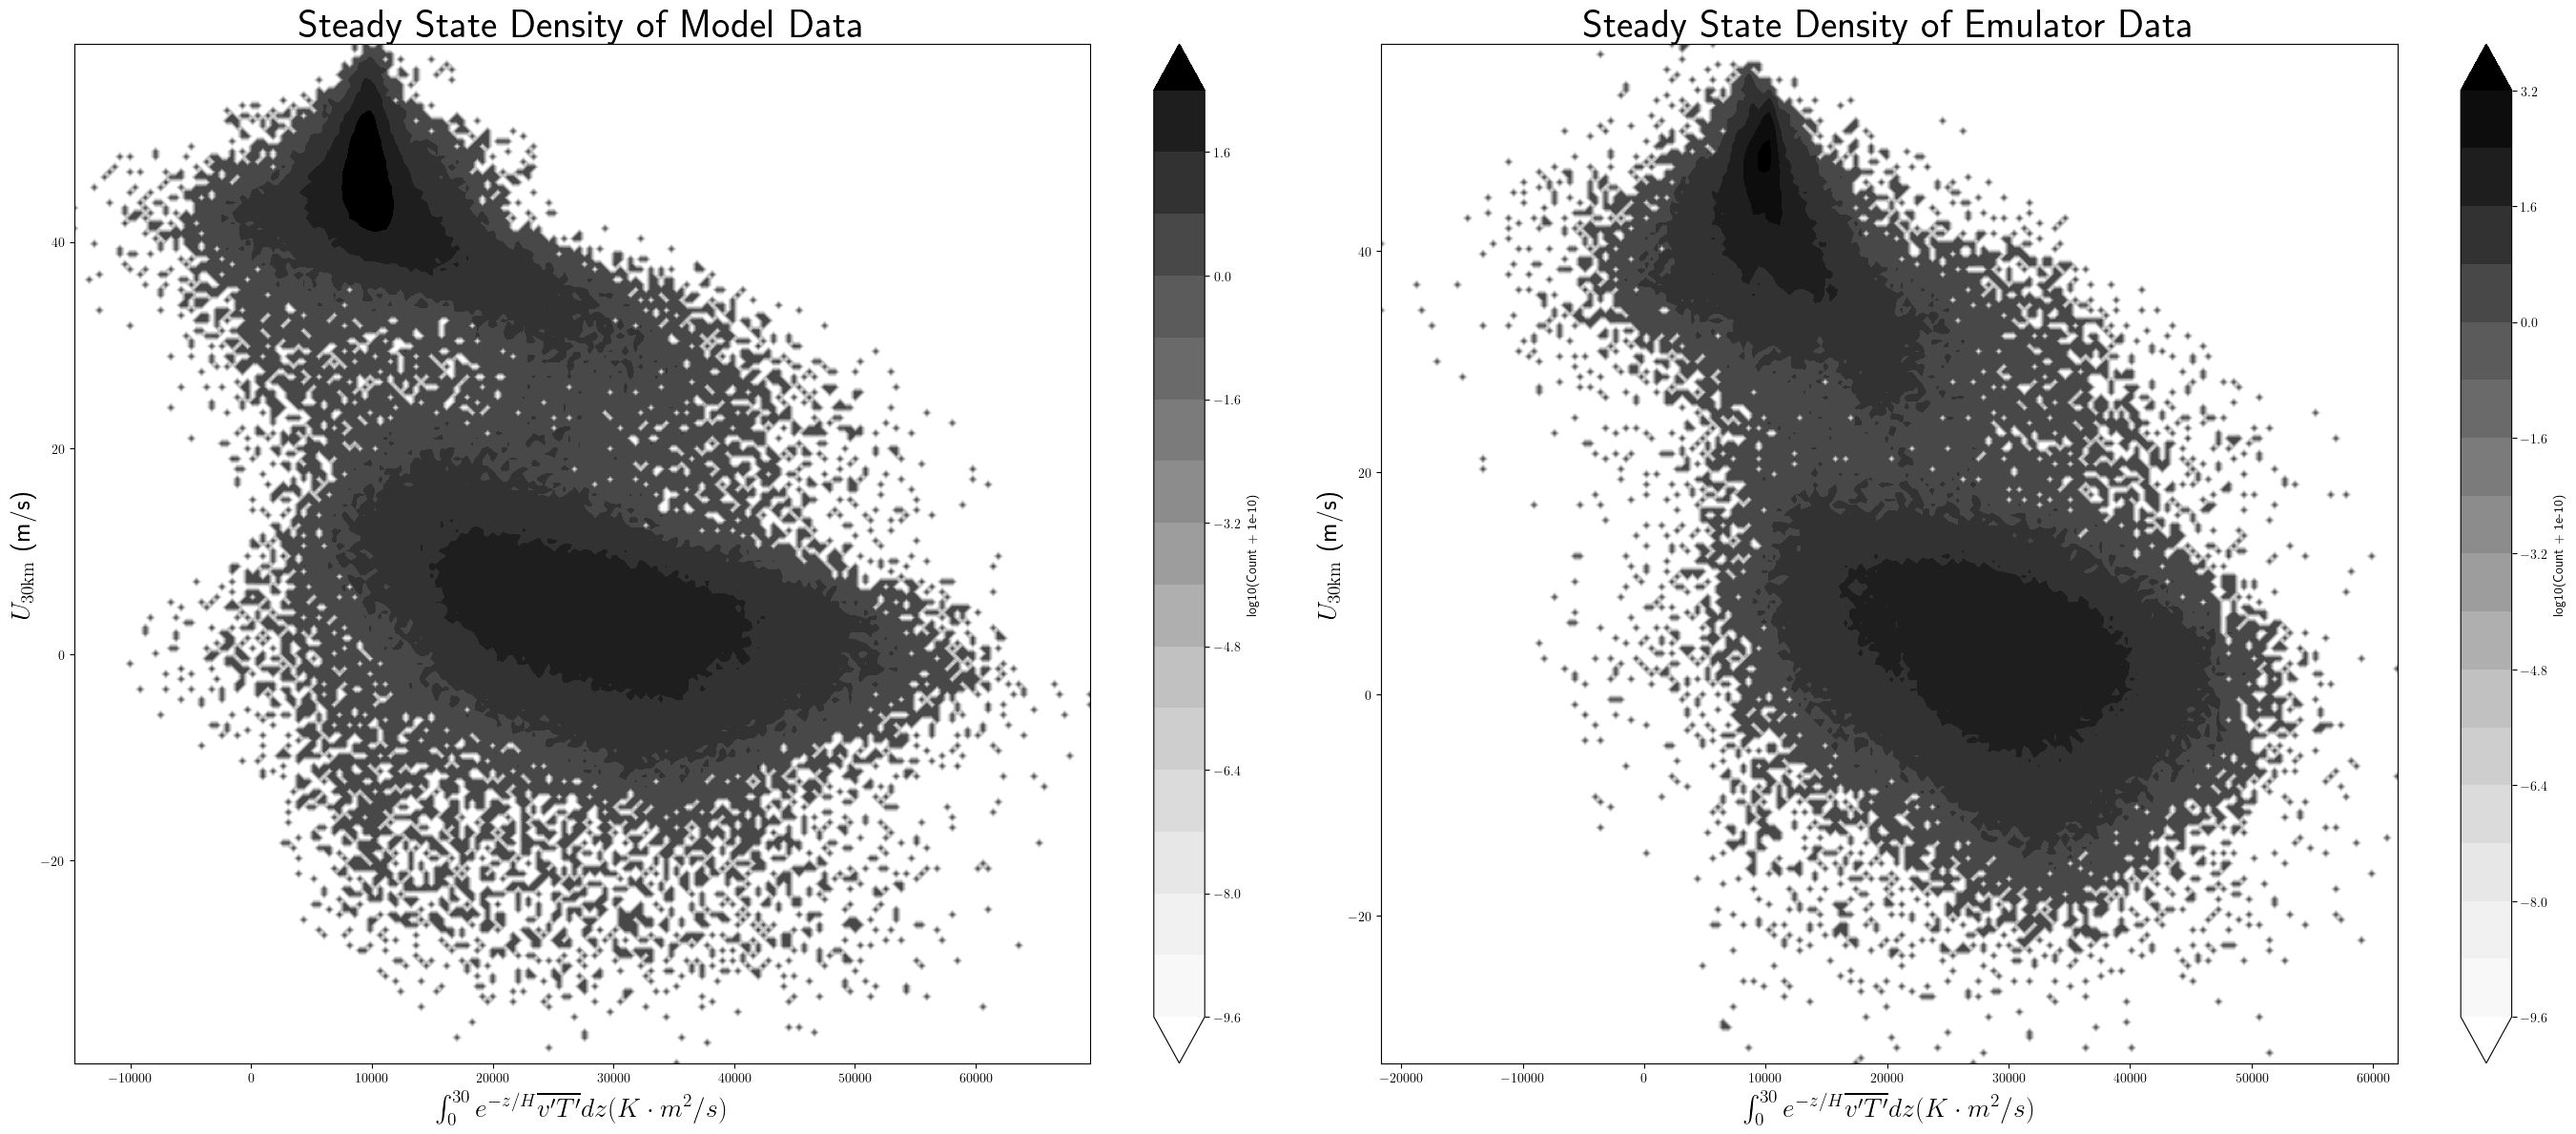

In [13]:

ssw_indices_A1, ssw_transition_lengths_A1, ssw_transition_values_A1 = detect_transitions_A_to_B(real_data[:timesteps, 1, 63], upper_bound, lower_bound)
ssw_indices_B1, ssw_transition_lengths_B1, ssw_transition_values_B1 = detect_transitions_B_to_A(real_data[:timesteps, 1, 63], upper_bound, lower_bound)

transition_indices = []
for length in ssw_transition_lengths_A1:
    start, end = length
    transition_indices.extend(range(start, end + 1))

total_len = len(real_data[:timesteps])
non_ssw_indices_B1 = np.where((real_data[:timesteps, 1, 63] < lower_bound) & (~np.isin(np.arange(total_len), np.union1d(ssw_indices_A1, ssw_indices_B1))))[0]
non_ssw_transition_values_B1 = zonal_wind[non_ssw_indices_B1]

condition = (real_data[:timesteps, 1, 63] >= lower_bound) & (real_data[:timesteps, 1, 63] <= upper_bound)
transition_region_indices = np.where(condition)[0]
print(len(transition_indices), len(transition_region_indices))

condition_A = (real_data[:timesteps, 1, 63] > upper_bound)
condition_B = (real_data[:timesteps, 1, 63] < lower_bound)
state_A_indices = np.where(condition_A)[0]
state_B_indices = np.where(condition_B)[0]
print(len(state_A_indices), len(state_B_indices))

# Density Contour Plot Data for Model and Emulator 

u30_bounds = [real_min_u, real_max_u]
psi30_bounds = [real_min_psi, real_max_psi]
ivt30_bounds = [real_min_ivt, real_max_ivt]

u30_bins = np.linspace(u30_bounds[0], u30_bounds[1], 101)
psi30_bins = np.linspace(psi30_bounds[0], psi30_bounds[1], 101)
ivt30_bins = np.linspace(ivt30_bounds[0], ivt30_bounds[1], 101)

real_ivt_13 = real_ivt[:, level-50]
density_u_psi, u_psi30_edges, psi_u30_edges = np.histogram2d(zonal_wind, real_streamfunction, bins=200)
density_u_ivt, u_ivt30_edges, ivt_u30_edges = np.histogram2d(zonal_wind, real_ivt_13, bins=200)
density_psi_ivt, psi_ivt30_edges, ivt_psi30_edges = np.histogram2d(real_streamfunction, real_ivt_13, bins=200)

density_log_u_psi = np.log10(density_u_psi + 1e-10)
density_log_u_ivt = np.log10(density_u_ivt + 1e-10)
density_log_psi_ivt = np.log10(density_psi_ivt + 1e-10)

u30_bounds = [min_u, max_u]
psi30_bounds = [min_psi, max_psi]
ivt30_bounds = [min_ivt, max_ivt]

u30_bins = np.linspace(u30_bounds[0], u30_bounds[1], 101)
psi30_bins = np.linspace(psi30_bounds[0], psi30_bounds[1], 101)
ivt30_bins = np.linspace(ivt30_bounds[0], ivt30_bounds[1], 101)

model_density_u_psi, model_u_psi30_edges, model_psi_u30_edges = np.histogram2d(save[:, level], streamfunction, bins=200)
model_density_u_ivt, model_u_ivt30_edges, model_ivt_u30_edges = np.histogram2d(save[:, level], ivt[:, level-50], bins=200)
model_density_psi_ivt, model_psi_ivt30_edges, model_ivt_psi30_edges = np.histogram2d(streamfunction, ivt[:, level-50], bins=200)

model_density_log_u_psi = np.log10(model_density_u_psi + 1e-10)
model_density_log_u_ivt = np.log10(model_density_u_ivt + 1e-10)
model_density_log_psi_ivt = np.log10(model_density_psi_ivt + 1e-10)

vmin_common = min(np.min(density_log_u_ivt), np.min(model_density_log_u_ivt))
vmax_common = max(np.max(density_log_u_ivt), np.max(model_density_log_u_ivt))

# Model Data Density Contour Plot

U30, IVT30 = np.meshgrid(u_ivt30_edges[:-1], ivt_u30_edges[:-1], indexing='ij')

fig, ax = plt.subplots(1, 2, figsize=(28, 12))

im1 = ax[0].contourf(IVT30.T * 4000, U30.T * 2, density_log_u_ivt.T, 
                levels=20, cmap='Greys', vmin = vmin_common, vmax = vmax_common, extend='both')

ax[0].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$", fontsize=20)
ax[0].set_ylabel(r'$U_{30\mathrm{km}}$ (m/s)', fontsize=20)
ax[0].set_title('Steady State Density of Model Data', fontweight='bold', fontsize=30)
ax[0].set_facecolor('white')

plt.colorbar(im1, ax=ax[0], label='log10(Count + 1e-10)')
plt.grid()

# Emulator Data Density Contour Plot

U30, IVT30 = np.meshgrid(model_u_ivt30_edges[:-1], model_ivt_u30_edges[:-1], indexing='ij')

im2 = ax[1].contourf(IVT30.T * 4000, U30.T * 2, model_density_log_u_ivt.T, 
                levels=20, cmap='Greys', vmin = vmin_common, vmax = vmax_common, extend='both')

ax[1].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$", fontsize=20)
ax[1].set_ylabel(r'$U_{30\mathrm{km}}$ (m/s)', fontsize=20)
ax[1].set_title('Steady State Density of Emulator Data', fontweight='bold', fontsize=30)
ax[1].set_facecolor('white')
plt.colorbar(im2, ax=ax[1], label='log10(Count + 1e-10)')
plt.grid()
plt.tight_layout()
plt.show()

# Committor

In [ ]:
def create_committer_matrix(data_u, data_ivt, transition_indices, state_A_indices, state_B_indices, 
                          u_bounds, ivt_bounds, n_bins=200):
    """
    Create a committer matrix that tracks probability of A to B transitions.
    
    Args:
        data_u: Zonal wind values
        data_ivt: IVT values  
        transition_indices: Indices of points in transition region
        state_A_indices: Indices of points in state A
        state_B_indices: Indices of points in state B
        u_bounds: [min, max] bounds for zonal wind
        ivt_bounds: [min, max] bounds for IVT
        n_bins: Number of bins for discretization
    
    Returns:
        committor_matrix: Matrix with transition probabilities
        u_edges, ivt_edges: Bin edges for plotting
    """
    
    # Initialize matrices
    transition_counts = np.zeros((n_bins, n_bins))  # Count of transitions to B
    total_counts = np.zeros((n_bins, n_bins))       # Total count of visits
    committor_matrix = np.full((n_bins, n_bins), np.nan)
    
    # Create bins
    u_edges = np.linspace(u_bounds[0], u_bounds[1], n_bins + 1)
    ivt_edges = np.linspace(ivt_bounds[0], ivt_bounds[1], n_bins + 1)
    u_bin_size = (u_bounds[1] - u_bounds[0]) / n_bins
    ivt_bin_size = (ivt_bounds[1] - ivt_bounds[0]) / n_bins
    
    # Process all data points to count visits
    for i in range(len(data_u)):
        u_val = data_u[i]
        ivt_val = data_ivt[i]
        
        # Find bin indices
        u_bin = int((u_val - u_bounds[0]) / u_bin_size)
        ivt_bin = int((ivt_val - ivt_bounds[0]) / ivt_bin_size)
        
        # Ensure bins are within bounds
        u_bin = min(max(u_bin, 0), n_bins - 1)
        ivt_bin = min(max(ivt_bin, 0), n_bins - 1)
        
        # Count total visits
        total_counts[u_bin, ivt_bin] += 1
        
        # If this point is in transition region, check if it leads to state B
        if i in transition_indices:
            # Look ahead to see if this transition leads to state B
            # Find the next state this point transitions to
            future_window = min(1000, len(data_u) - i - 1)  # Look ahead up to 1000 steps
            
            for j in range(1, future_window + 1):
                future_idx = i + j
                if future_idx in state_B_indices:
                    transition_counts[u_bin, ivt_bin] += 1
                    break
                elif future_idx in state_A_indices:
                    # Went back to A, don't count as transition to B
                    break
    
    # Calculate probabilities only where we have data
    mask = total_counts > 0
    committor_matrix[mask] = transition_counts[mask] / total_counts[mask]
    print(committor_matrix[mask], transition_counts[mask], total_counts[mask])
    # Set boundary conditions only for bins with data
    for i in range(n_bins):
        for j in range(n_bins):
            if total_counts[i, j] > 0:  # Only set if we have data in this bin
                u_center = u_bounds[0] + (i + 0.5) * u_bin_size
                
                # State A: probability = 0
                if u_center > upper_bound:
                    committor_matrix[i, j] = 0.0
                
                # State B: probability = 1  
                elif u_center < lower_bound:
                    committor_matrix[i, j] = 1.0
    
    return committor_matrix, u_edges, ivt_edges
# real_data = real_data[:, 1, :]

Creating committer matrix for real data...
[[0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.000e+00 2.510e+02 1.710e+03 1.134e+03 5.350e+02 2.080e+02
  5.300e+01 9.000e+00 0.000e+00]
 [0.000e+00 3.000e+00 8.600e+01 4.360e+02 8.550e+02 1.144e+03 4.590e+02
  8.900e+01 9.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 2.000e+00 3.710e+02 1.469e+03 8.800e+02 1.210e+02
  7.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 

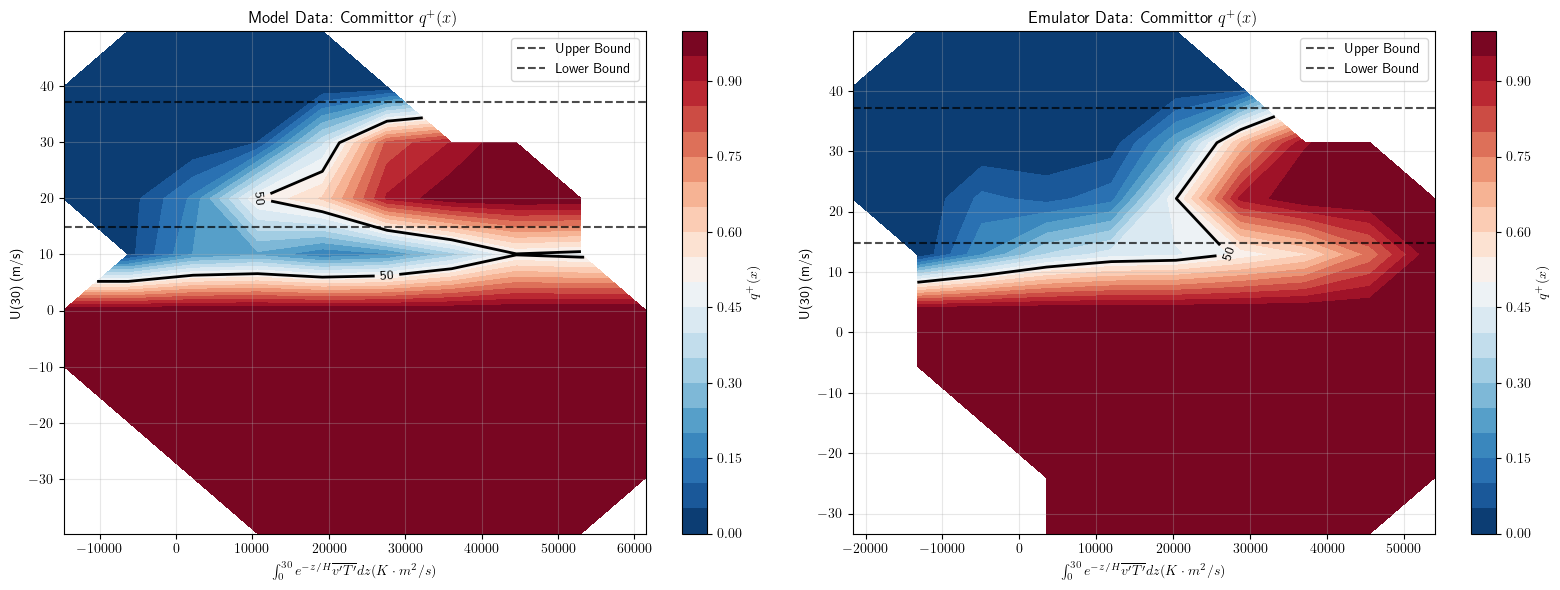


Real Data Statistics:
Points in state A: 145219
Points in state B: 137569
Points in transition region: 17212
Valid committor values: 78/100

Model Data Statistics:
Points in state A: 133524
Points in state B: 143643
Points in transition region: 22833
Valid committor values: 79/100

Transition Region Analysis:
Real data - Mean transition probability: 0.685
Model data - Mean transition probability: 0.644


In [17]:
from matplotlib import axes

real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
real_data = real_data[:, 1, :]
real_data = real_data[:timesteps, :]
# Real U(30)
rmin1   = np.min(real_data[:, level])
rmax1   = np.max(real_data[:, level])
rrange1 = rmax1 - rmin1
rud     = real_data[:, level]

# Real |PSI(30)|
rmin2   = np.min(np.sqrt(real_data[:,:n]**2+real_data[:,n:2*n]**2)[:, level-50])
rmax2   = np.max(np.sqrt(real_data[:,:n]**2+real_data[:,n:2*n]**2)[:, level-50])
rrange2 = rmax2 - rmin2
rpsid     = np.sqrt(real_data[:,:n]**2+real_data[:,n:2*n]**2)[:, level-50]

# Real IHF(30)
rmin3   = np.min(real_ivt[:, level-50])
rmax3   = np.max(real_ivt[:, level-50])
rrange3 = rmax3 - rmin3
ruhf     = real_ivt[:, level-50]

# Model U(30)
min1   = np.min(save[:, level])
max1   = np.max(save[:, level])
range1 = max1 - min1
mud     = save[:, level]

# Model |PSI(30)|
min2   = np.min(np.sqrt(save[:,:n]**2+save[:,n:2*n]**2)[:, level-50])
max2   = np.max(np.sqrt(save[:,:n]**2+save[:,n:2*n]**2)[:, level-50])
range2 = max2 - min2
mpsid     = np.sqrt(save[:,:n]**2+save[:,n:2*n]**2)[:, level-50]

# Model IHF(30)
min3   = np.min(ivt[:, level-50])
max3   = np.max(ivt[:, level-50])
range3 = max3 - min3
muhf     = ivt[:, level-50]

# Real Transition region indices
cd = (real_data[:, level] <= upper_bound) & (real_data[:, level] >= lower_bound)
rT_idxs = np.where(cd)[0]

# Real State A and B indices
cd_A = (real_data[:, level] > upper_bound)
cd_B = (real_data[:, level] < lower_bound)
rA_idxs = np.where(cd_A)[0]
rB_idxs = np.where(cd_B)[0]

# Model Transition region indices
mcd = (save[:, level] <= upper_bound) & (save[:, level] >= lower_bound)
mT_idxs = np.where(mcd)[0]

# Model State A and B indices
mcd_A = (save[:, level] > upper_bound)
mcd_B = (save[:, level] < lower_bound)
mA_idxs = np.where(mcd_A)[0]
mB_idxs = np.where(mcd_B)[0]

# Committer plot function

def committer_plot(rmin1, rmax1, rmin2, rmax2, r1d, r2d, min1, max1, min2, max2, 
                   m1d, m2d, n, l, rT_idxs, rA_idxs, rB_idxs, mT_idxs, mA_idxs, mB_idxs, up, lw, n_bins):

    print("Creating committer matrix for real data...")
    # Create committer matrix for real data
    rcomm, r1_edges, r2_edges = create_committer_matrix(
        r1d, r2d, rT_idxs, rA_idxs, rB_idxs,[rmin1, rmax1], [rmin2, rmax2], n_bins)

    print("Creating committer matrix for model data...")
    # Create committer matrix for model data
    mcomm, m1_edges, m2_edges = create_committer_matrix(
        m1d, m2d, mT_idxs, mA_idxs, mB_idxs, [min1, max1], [min2, max2], n_bins)

    # Plotting with white background for no data
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Create custom colormap with white for NaN values
    from matplotlib.colors import ListedColormap
    from matplotlib.cm import RdBu_r
    import matplotlib.colors as mcolors

    # Get the RdBu_r colormap
    cmap = plt.cm.RdBu_r
    # Set the color for bad/missing values to white
    cmap.set_bad(color='white')

    # Real data committor
    r1, r2 = np.meshgrid(r1_edges[:-1], r2_edges[:-1], indexing='ij')
    # Mask NaN values for white background
    rcomm_masked = np.ma.masked_invalid(rcomm)

    for prob in rcomm:
        sum_prob = 0
        for val in prob:
            if val == 1.0:
                sum_prob += 1
        if sum_prob == len(prob)/2:
            print("Found 50% probability line in real data committor.")
            axes[0].axhline(y=r1[prob], color='black', linestyle='--', alpha=0.7)

    im1 = axes[0].contourf(r2.T * 4000, r1.T * 2, rcomm_masked.T, 
                        levels=20, cmap=cmap, vmin=0, vmax=1, extend='neither')

    contour_50 = axes[0].contour(r2.T * 4000, r1.T * 2, rcomm_masked.T, 
                                 levels=[0.5], colors='black', linewidths=2)
    axes[0].clabel(contour_50, fmt={0.5: '50%'}, inline=True, fontsize=10)

    axes[0].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$")
    axes[0].set_ylabel(r'U(30) (m/s)')
    axes[0].set_title(r'Model Data: Committor $q^+(x)$')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_facecolor('white')

    plt.colorbar(im1, ax=axes[0], label=r'$q^+(x)$')

    # Add boundary lines
    axes[0].axhline(y=up * 2, color='black', linestyle='--', alpha=0.7, label='Upper Bound')
    axes[0].axhline(y=lw * 2, color='black', linestyle='--', alpha=0.7, label='Lower Bound')
    axes[0].legend()

    # Model data committor
    m1, m2 = np.meshgrid(m1_edges[:-1], m2_edges[:-1], indexing='ij')
    # Mask NaN values for white background
    mcomm_masked = np.ma.masked_invalid(mcomm)

    im2 = axes[1].contourf(m2.T * 4000, m1.T * 2, mcomm_masked.T, 
                        levels=20, cmap=cmap, vmin=0, vmax=1, extend='neither')

    contour_50_model = axes[1].contour(m2.T * 4000, m1.T * 2, mcomm_masked.T, 
                           levels=[0.5], colors='black', linewidths=2)
    axes[1].clabel(contour_50_model, fmt={0.5: '50%'}, inline=True, fontsize=10)

    axes[1].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$")
    axes[1].set_ylabel(r'U(30) (m/s)')
    axes[1].set_title(r'Emulator Data: Committor $q^+(x)$')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_facecolor('white')

    plt.colorbar(im2, ax=axes[1], label=r'$q^+(x)$')

    # Add boundary lines
    axes[1].axhline(y=up * 2, color='black', linestyle='--', alpha=0.7, label='Upper Bound')
    axes[1].axhline(y=lw * 2, color='black', linestyle='--', alpha=0.7, label='Lower Bound')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nReal Data Statistics:")
    print(f"Points in state A: {len(rA_idxs)}")
    print(f"Points in state B: {len(rB_idxs)}")
    print(f"Points in transition region: {len(rT_idxs)}")
    print(f"Valid committor values: {np.sum(~np.isnan(rcomm))}/{rcomm.size}")

    print(f"\nModel Data Statistics:")
    print(f"Points in state A: {len(mA_idxs)}")
    print(f"Points in state B: {len(mB_idxs)}")
    print(f"Points in transition region: {len(mT_idxs)}")
    print(f"Valid committor values: {np.sum(~np.isnan(mcomm))}/{mcomm.size}")

    # Calculate average transition probabilities in transition region
    real_transition_probs = rcomm[~np.isnan(rcomm)]
    model_transition_probs = mcomm[~np.isnan(mcomm)]

    print(f"\nTransition Region Analysis:")
    print(f"Real data - Mean transition probability: {np.mean(real_transition_probs):.3f}")
    print(f"Model data - Mean transition probability: {np.mean(model_transition_probs):.3f}")

committer_plot(rmin1, rmax1, rmin3, rmax3, rud, ruhf, min1, max1, min3, max3,
               mud, muhf, n, level, rT_idxs, rA_idxs, rB_idxs, mT_idxs, mA_idxs,
               mB_idxs, upper_bound, lower_bound, n_bins=10)

# Lead Time

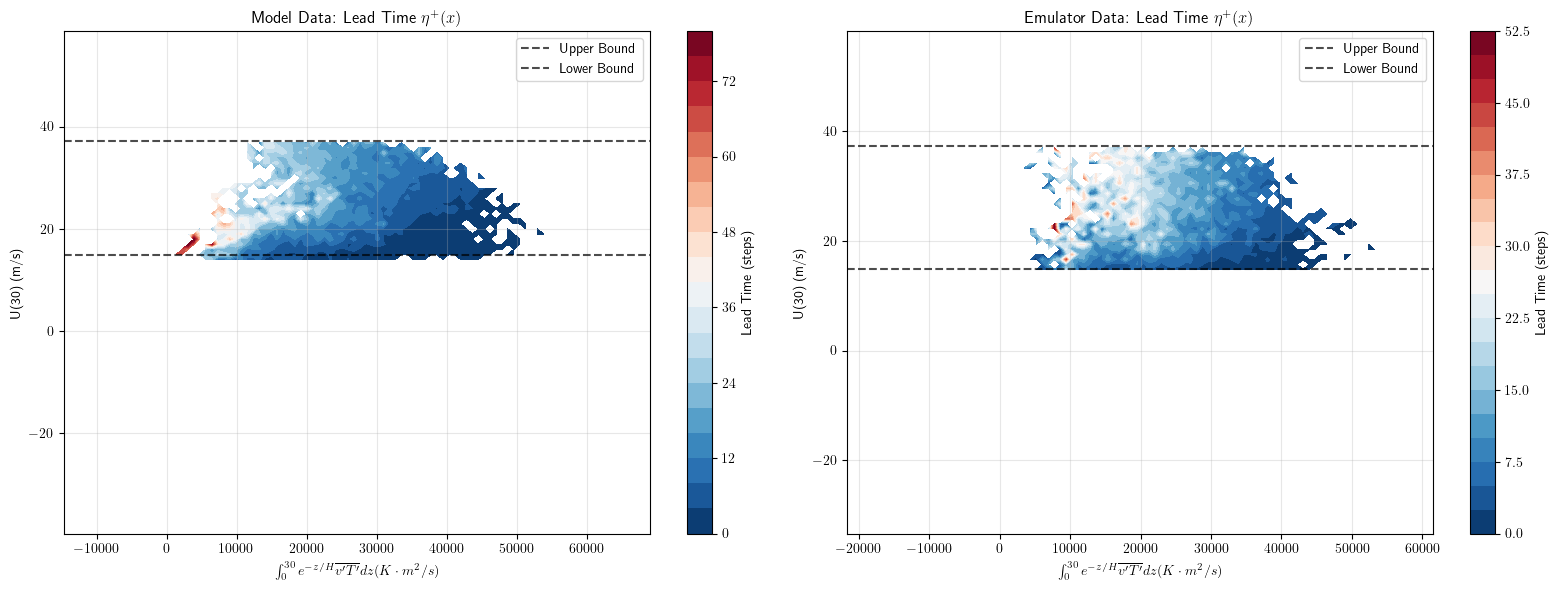

In [65]:
def lead_time_matrix(d1, d2, T_idxs, A_idxs, B_idxs, 
                     bs1, bs2, n_bins):
    
    # Initialize matrices
    lead_times_sum = np.zeros((n_bins, n_bins))  # Sum of lead times
    lead_times_count = np.zeros((n_bins, n_bins))  # Count of transitions
    lead_time_matrix = np.full((n_bins, n_bins), np.nan)
    
    # Create bins
    edg1 = np.linspace(bs1[0], bs1[1], n_bins + 1)
    edg2 = np.linspace(bs2[0], bs2[1], n_bins + 1)
    bsize1 = (bs1[1] - bs1[0]) / n_bins
    bsize2 = (bs2[1] - bs2[0]) / n_bins
    
    # Process all data points to count das
    for i in range(len(d1)):
        if i in T_idxs:
            u_val = d1[i]
            ivt_val = d2[i]
            
            # Find bin indices
            u_bin = int((u_val - bs1[0]) / bsize1)
            ivt_bin = int((ivt_val - bs2[0]) / bsize2)
            
            # Ensure bins are within bounds
            u_bin = min(max(u_bin, 0), n_bins - 1)
            ivt_bin = min(max(ivt_bin, 0), n_bins - 1)
            
            # Count total visits
            future_window = min(1000, len(d1) - i - 1)  # Look ahead up to 1000 steps
            
            for j in range(1, future_window + 1):
                future_idx = i + j
                if future_idx in B_idxs:
                    lead_times_sum[u_bin, ivt_bin] += j
                    lead_times_count[u_bin, ivt_bin] += 1
                    break
                elif future_idx in A_idxs:
                    # Went back to A, don't count as transition to B
                    break

    mask = lead_times_count > 0
    lead_time_matrix[mask] = lead_times_sum[mask] / lead_times_count[mask]

    return lead_time_matrix, edg1, edg2

rlead_times, r1_edges, r2_edges = lead_time_matrix(rud, ruhf, rT_idxs, rA_idxs, rB_idxs, [rmin1, rmax1], [rmin3, rmax3], n_bins=100)

mlead_times, m1_edges, m2_edges = lead_time_matrix(mud, muhf, mT_idxs, mA_idxs, mB_idxs, [min1, max1], [min3, max3], n_bins=100)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Get the RdBu_r colormap
cmap = plt.cm.RdBu_r
# Set the color for bad/missing values to white
cmap.set_bad(color='white')

# Real data committor
r1, r2 = np.meshgrid(r1_edges[:-1], r2_edges[:-1], indexing='ij')
# Mask NaN values for white background
rlead_masked = np.ma.masked_invalid(rlead_times)

im1 = axes[0].contourf(r2.T * 4000, r1.T * 2, rlead_masked.T, 
                    levels=20, cmap=cmap, extend='neither')

axes[0].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$")
axes[0].set_ylabel(r'U(30) (m/s)')
axes[0].set_title(r'Model Data: Lead Time $\eta^+(x)$')
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

plt.colorbar(im1, ax=axes[0], label='Lead Time (steps)')

# Add boundary lines
axes[0].axhline(y=upper_bound*2, color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[0].axhline(y=lower_bound*2, color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[0].legend()

# Model data committor
m1, m2 = np.meshgrid(m1_edges[:-1], m2_edges[:-1], indexing='ij')
# Mask NaN values for white background
mlead_masked = np.ma.masked_invalid(mlead_times)

im2 = axes[1].contourf(m2.T * 4000, m1.T * 2, mlead_masked.T, 
                    levels=20, cmap=cmap, extend='neither')

axes[1].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$")
axes[1].set_ylabel(r'U(30) (m/s)')
axes[1].set_title(r'Emulator Data: Lead Time $\eta^+(x)$')
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('white')

plt.colorbar(im2, ax=axes[1], label='Lead Time (steps)')

# Add boundary lines
axes[1].axhline(y=upper_bound*2, color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[1].axhline(y=lower_bound*2, color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[1].legend()

plt.tight_layout()
plt.show()

# Paths

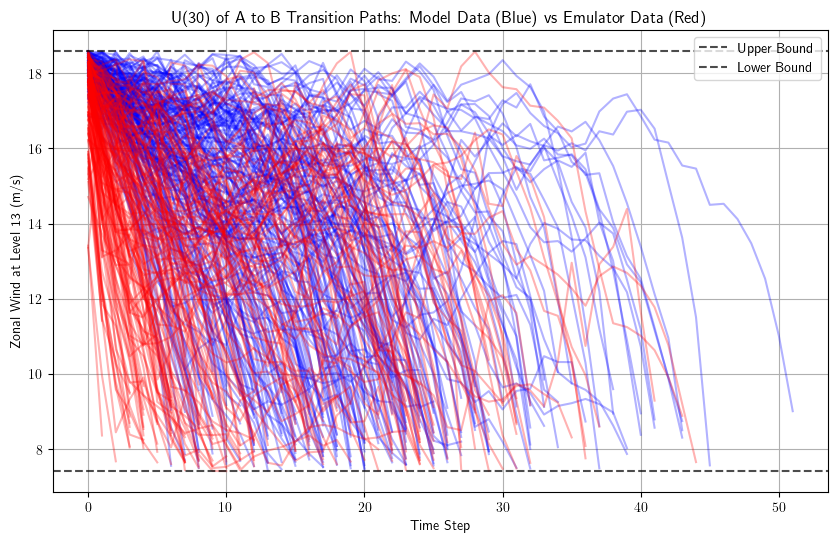

In [39]:
plt.figure(figsize=(10,6))
for path in real_paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    plt.plot(real_data[start_of_path:end_of_path, level], color='blue', alpha=0.3)
for path in paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    plt.plot(save[start_of_path:end_of_path, level], color='red', alpha=0.3)
plt.axhline(y=upper_bound, color='black', linestyle='--', alpha=0.7, label='Upper Bound')
plt.axhline(y=lower_bound, color='black', linestyle='--', alpha=0.7, label='Lower Bound')
plt.xlabel('Time Step')
plt.ylabel('Zonal Wind at Level 13 (m/s)')
plt.title('U(30) of A to B Transition Paths: Model Data (Blue) vs Emulator Data (Red)')
plt.legend()
plt.grid()
plt.show()

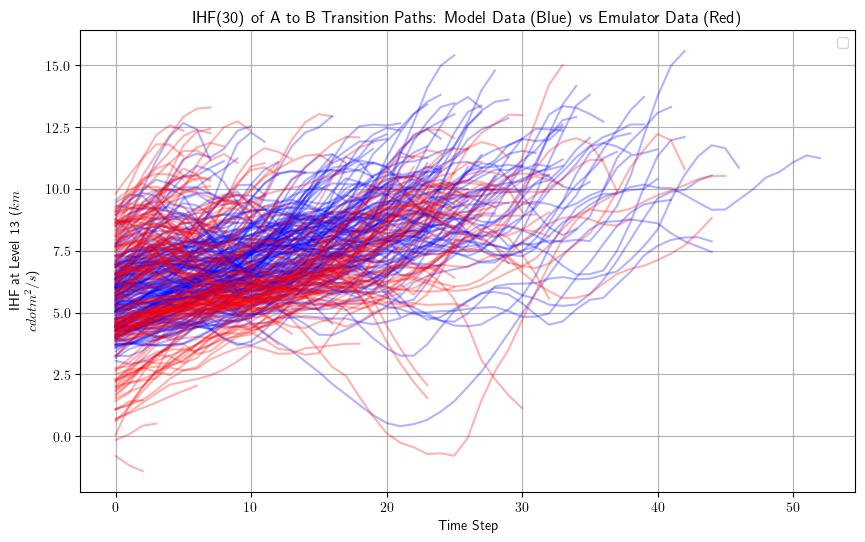

In [41]:
plt.figure(figsize=(10,6))
for path in real_paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    plt.plot(real_ivt[start_of_path:end_of_path + 1, level-50], color='blue', alpha=0.3)
for path in paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    plt.plot(ivt[start_of_path:end_of_path + 1, level-50], color='red', alpha=0.3)
# plt.axhline(y=upper_bound, color='black', linestyle='--', alpha=0.7, label='Upper Bound')
# plt.axhline(y=lower_bound, color='black', linestyle='--', alpha=0.7, label='Lower Bound')
plt.xlabel('Time Step')
plt.ylabel(r'IHF at Level 13 ($km\\cdot m^2/s$)')
plt.title('IHF(30) of A to B Transition Paths: Model Data (Blue) vs Emulator Data (Red)')
plt.legend()
plt.grid()
plt.show()

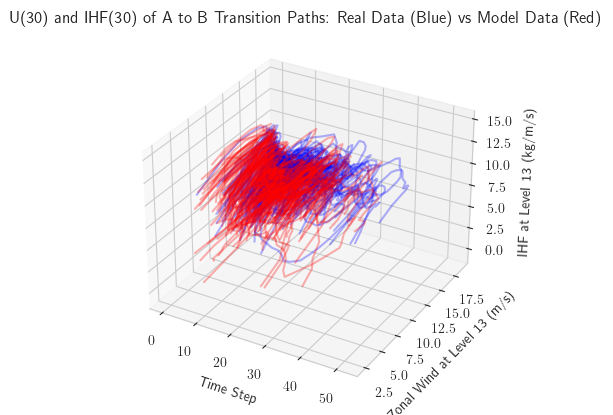

In [74]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for path in real_paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    length = end_of_path - start_of_path + 1
    time = np.arange(length)
    ax.plot(time, real_data[start_of_path:end_of_path + 1, level], real_ivt[start_of_path:end_of_path + 1, level-50], color='blue', alpha=0.3)

for path in paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    length = end_of_path - start_of_path + 1
    time = np.arange(length)
    ax.plot(time, save[start_of_path:end_of_path + 1, level], ivt[start_of_path:end_of_path + 1, level-50], color='red', alpha=0.3)

ax.set_xlabel('Time Step')
ax.set_ylabel('Zonal Wind at Level 13 (m/s)')
ax.set_zlabel('IHF at Level 13 (kg/m/s)')
ax.set_title('U(30) and IHF(30) of A to B Transition Paths: Real Data (Blue) vs Model Data (Red)')
plt.show()


In [42]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

fig = go.Figure()
for path in real_paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    length = end_of_path - start_of_path + 1
    time = np.arange(length)
    data = {
        'time': time,
        'zonal_wind': real_data[start_of_path:end_of_path + 1, level],
        'ihf': real_ivt[start_of_path:end_of_path + 1, level-50]
    }
    df = pd.DataFrame(data)
    fig.add_trace(go.Scatter3d(x=df['time'], y=df['zonal_wind'], z=df['ihf'], 
                               mode='lines', line=dict(color='red', width=2), 
                               name='Model Data', legendgroup='Model Data',
                               showlegend=True if start_of_path == real_paths[1][0] else False))

for path in paths[1::2]:  # Step by 2 to get only A to B transitions
    start_of_path, end_of_path = path
    length = end_of_path - start_of_path + 1
    time = np.arange(length)
    data = {
        'time': time,
        'zonal_wind': save[start_of_path:end_of_path + 1, level],
        'ihf': ivt[start_of_path:end_of_path + 1, level-50]
    }
    df = pd.DataFrame(data)
    fig.add_trace(go.Scatter3d(x=df['time'], y=df['zonal_wind'], z=df['ihf'], 
                               mode='lines', line=dict(color='blue', width=2), 
                               name='Emulator Data', legendgroup='Emulator Data',
                               showlegend=True if start_of_path == paths[1][0] else False))

fig.update_layout(
    scene = dict(
        xaxis_title='Time Step',
        yaxis_title='U(30)',
        zaxis_title='IHF(30)'
    ),
    title='U(30) and IHF(30) of A to B Transition Paths: Model Data vs Emulator Data',
    width=800,
    height=600,
)
fig.show()

# Conditional Density A to B Transitions

In [14]:
real_data = real_data[:timesteps, 1, :]

4464 17212
145219 137569
2825 22833
133524 143643


ValueError: x and y must have same first dimension, but have shapes (0,) and (14,)

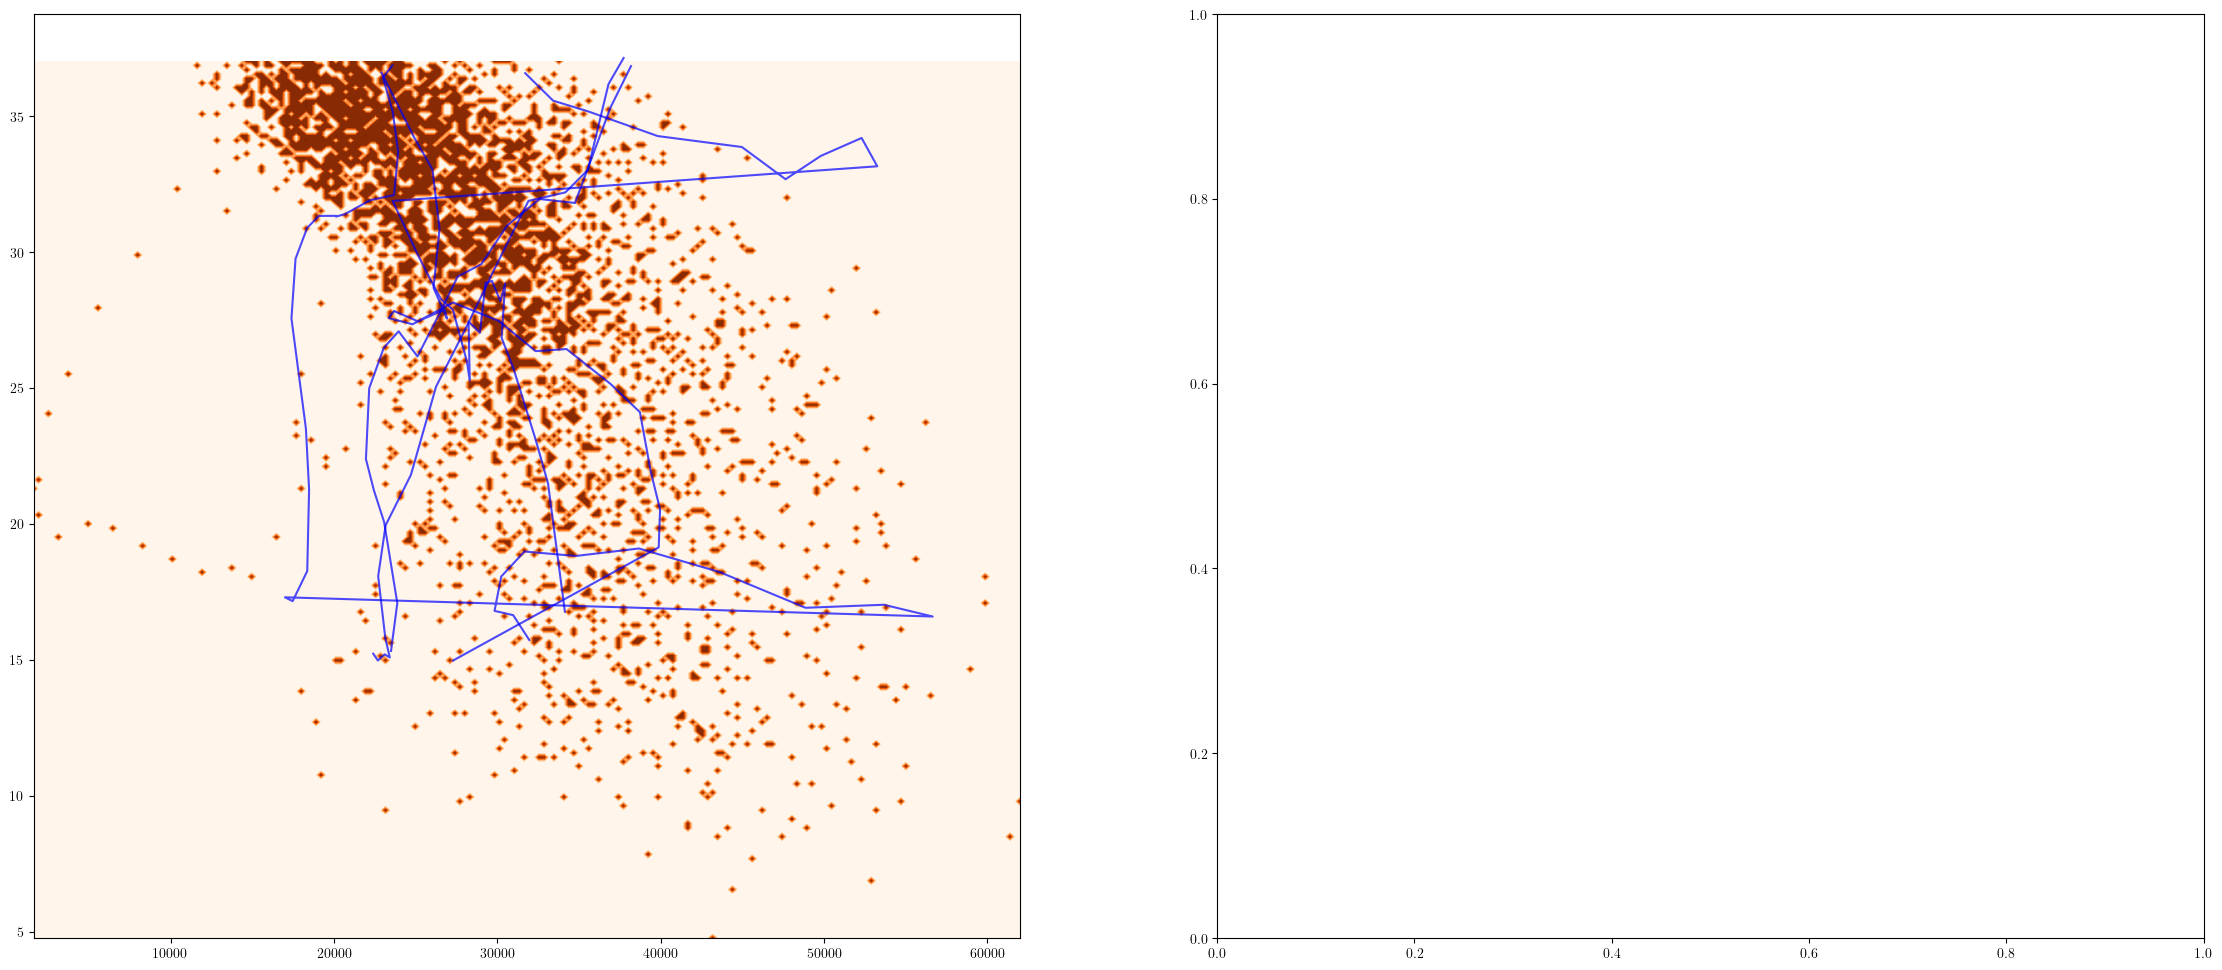

In [26]:
# Real AB

ssw_indices_A1, ssw_transition_lengths_A1, ssw_transition_values_A1 = detect_transitions_A_to_B(real_data[:timesteps, 63], upper_bound, lower_bound)
ssw_indices_B1, ssw_transition_lengths_B1, ssw_transition_values_B1 = detect_transitions_B_to_A(real_data[:timesteps, 63], upper_bound, lower_bound)

transition_indices = []
for length in ssw_transition_lengths_A1:
    start, end = length
    transition_indices.extend(range(start, end + 1))

total_len = len(real_data[:timesteps])
non_ssw_indices_B1 = np.where((real_data[:timesteps, 63] < lower_bound) & (~np.isin(np.arange(total_len), np.union1d(ssw_indices_A1, ssw_indices_B1))))[0]
non_ssw_transition_values_B1 = zonal_wind[non_ssw_indices_B1]

condition = (real_data[:timesteps, 63] >= lower_bound) & (real_data[:timesteps, 63] <= upper_bound)
transition_region_indices = np.where(condition)[0]
print(len(transition_indices), len(transition_region_indices))

condition_A = (real_data[:timesteps, 63] > upper_bound)
condition_B = (real_data[:timesteps, 63] < lower_bound)
state_A_indices = np.where(condition_A)[0]
state_B_indices = np.where(condition_B)[0]
print(len(state_A_indices), len(state_B_indices))

transition_indices = np.array(transition_indices)
rt_data = real_data[transition_indices]
n = q['Nz']-1
x = rt_data  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
real_ivt = np.zeros((Nt,n))
real_ivt[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    real_ivt[:,i] = real_ivt[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

# Model AB

ssw_indices_A1, ssw_transition_lengths_A1, ssw_transition_values_A1 = detect_transitions_A_to_B(save[:timesteps, 63], upper_bound, lower_bound)
ssw_indices_B1, ssw_transition_lengths_B1, ssw_transition_values_B1 = detect_transitions_B_to_A(save[:timesteps, 63], upper_bound, lower_bound)

model_transition_indices = []
for length in ssw_transition_lengths_A1:
    start, end = length
    model_transition_indices.extend(range(start, end + 1))

total_len = len(save[:timesteps])
non_ssw_indices_B1 = np.where((save[:timesteps, 63] < lower_bound) & (~np.isin(np.arange(total_len), np.union1d(ssw_indices_A1, ssw_indices_B1))))[0]
non_ssw_transition_values_B1 = zonal_wind[non_ssw_indices_B1]

condition = (save[:timesteps, 63] >= lower_bound) & (save[:timesteps, 63] <= upper_bound)
transition_region_indices = np.where(condition)[0]
print(len(model_transition_indices), len(transition_region_indices))

condition_A = (save[:timesteps, 63] > upper_bound)
condition_B = (save[:timesteps, 63] < lower_bound)
state_A_indices = np.where(condition_A)[0]
state_B_indices = np.where(condition_B)[0]
print(len(state_A_indices), len(state_B_indices))

model_transition_indices = np.array(model_transition_indices)
mt_data = save[model_transition_indices]
n = q['Nz']-1
x = mt_data  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
ivt = np.zeros((Nt,n))
ivt[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    ivt[:,i] = ivt[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

# Density Contour Plots for Real Data

rAB_U30 = real_data[:, level][transition_indices]
rAB_PSI30 = real_streamfunction[transition_indices]
rAB_IVT30 = real_ivt[:, level-50]

density_u_ivt, u_ivt30_edges, ivt_u30_edges = np.histogram2d(rAB_U30, rAB_IVT30, bins=200)

density_log_u_ivt = np.log10(density_u_ivt + 1e-10)

U30, IVT30 = np.meshgrid(u_ivt30_edges[:-1], ivt_u30_edges[:-1], indexing='ij')

np_real_paths = np.array(real_paths)
rs_indices = np.random.choice(np_real_paths.shape[0], size=10, replace=False)
rs_paths = np_real_paths[rs_indices]

fig, ax = plt.subplots(1, 2, figsize=(28, 12))

im = ax[0].contourf(IVT30.T * 4000, U30.T * 2, density_log_u_ivt.T,
                levels=20, cmap='Oranges', extend='both')
for path in real_paths:
    start_of_path, end_of_path = path
    ax[0].plot(real_ivt[start_of_path:end_of_path, level-50] * 4000, real_data[start_of_path:end_of_path, level] * 2, color='blue', alpha=0.7)

ax[0].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$")
ax[0].set_ylabel(r'$U_{30\mathrm{km}}$ (m/s)')
ax[0].set_title('(a) Density of x', fontweight='bold')
ax[0].set_facecolor('white')

plt.colorbar(im, ax=ax[0], label='log10(Count + 1e-10)')
plt.grid()

# Density Contour Plots for Model Data

mAB_U30 = save[:, level][model_transition_indices]
mAB_PSI30 = streamfunction[model_transition_indices]
mAB_IVT30 = ivt[:, level-50]

density_u_ivt, u_ivt30_edges, ivt_u30_edges = np.histogram2d(mAB_U30, mAB_IVT30, bins=200)

density_log_u_ivt = np.log10(density_u_ivt + 1e-10)

U30, IVT30 = np.meshgrid(u_ivt30_edges[:-1], ivt_u30_edges[:-1], indexing='ij')

np_mpaths = np.array(paths)
m_indices = np.random.choice(np_mpaths.shape[0], size=10, replace=False)
m_paths = np_mpaths[m_indices]

im = ax[1].contourf(IVT30.T * 4000, U30.T * 2, density_log_u_ivt.T, 
                levels=20, cmap='Oranges', extend='both')
for path in paths:
    start_of_path, end_of_path = path
    ax[1].plot(ivt[start_of_path:end_of_path, level-50] * 4000, save[start_of_path:end_of_path, level] * 2, color='red', alpha=0.7)

ax[1].set_xlabel(r"$\int_{0}^{30}e^{-z/H}\overline{v'T'}dz(K\cdot m^2 / s)$")
ax[1].set_ylabel(r'$U_{30\mathrm{km}}$ (m/s)')
ax[1].set_title('(b) Density of x', fontweight='bold')
ax[1].set_facecolor('white')
plt.colorbar(im, ax=ax[1], label='log10(Count + 1e-10)')
plt.grid()
plt.tight_layout()
plt.show()